## adapt the new bootstrapping method

In [3]:
import numpy as np
import scipy
import scipy.stats
import sqlite3
import json
import os
import pickle as pkl
from copy import deepcopy
from datetime import datetime
import matplotlib.pyplot as plt
from mpmath import mp
import statsmodels.stats
import statsmodels.stats.weightstats
import statsmodels.stats.diagnostic
import scipy.stats
from scipy.stats import f_oneway
import statsmodels.stats.oneway

In [4]:
COND_LIST = ['normal1', 'jigsaw1', 'jigsaw2', 'jigsaw3', 'blur1', 'blur2', 'blur3', 'blur4', 'blur5', 'amount1', 'amount2', 'amount3', 'amount4', 'amount5']
COND_DICT = {k:v for v,k in enumerate(COND_LIST)}

## Get human data

In [5]:
def retrieve_dummy_results(data_entry,print_flag=True):
    dummy_results = []
    cnt = 0
    for entry in data_entry['data']:
        
        if 'imageID' not in entry['trialdata']:
            continue
        if 'dummy' in entry['trialdata']['imageID'] or 'test_control' in entry['trialdata']['imageID']:
            dummy_results.append([cnt, entry['trialdata']['phase'],entry['trialdata']['imageID'], entry['trialdata']['response']])
            if print_flag:
                print(cnt, entry['trialdata']['phase'],entry['trialdata']['imageID'], entry['trialdata']['response'])
            cnt += 1
    return dummy_results

def retrieve_metadata(data):
    metadata = {}
    metadata[names[0]] = data[0]
    metadata[names[2]] = data[2]
    metadata[names[4]] = data[4]
    metadata[names[11]] = data[11]
    metadata[names[12]] = data[12]
    metadata[names[13]] = data[13]
    return metadata

def retrieve_test_results(data_entry,print_flag=True):
    test_results = []
    cnt = 0
    for entry in data_entry['data']:
        if 'imageID' not in entry['trialdata']:
            continue
        if 'dummy' not in entry['trialdata']['imageID'] and 'fribble' in entry['trialdata']['imageID'] :
            test_results.append([cnt, entry['trialdata']['imageID'].split('/'), entry['trialdata']['response'], entry['trialdata']['rt']])
            if print_flag:
                print(cnt, entry['trialdata']['imageID'].split('/')[-2], entry['trialdata']['response'], entry['trialdata']['rt'])
            cnt += 1
    return test_results

def retrieve_supervision_mode_rule_cb(data_entry):
    dummy_results = []
    cnt = 0
    for entry in data_entry['data']:
        if 'imageID' not in entry['trialdata']:
            continue
        if 'dummy' in entry['trialdata']['imageID']:
            return conds[int(entry['trialdata']['phase'][-2])], int(entry['trialdata']['phase'][-1]), int(entry['trialdata']['counterbalance'])
        
        
def calculate_test_acc(test_results):
    assert len(test_results) == 40
    cnt = 0
    normal_total, normal_cnt = 0, 0
#     print(test_results[0])
#     assert 1 == 2
#     for _,phase,img_id,response in test_results:
    for _,img_id,response,rp in test_results:
        ori_img_id = randomized_names_reverse[img_id[-2]]
        answer = ori_img_id.split('/')[0].split('_')[-1]
        response = rand2fb[response]
#         print(answer,response)
        assert answer in ['fa1','fb1','fb3','fc1']
        cnt = cnt + 1 if answer == response else cnt + 0
        if len(ori_img_id.split('/')[-1].split('_')) == 6:
            normal_cnt = normal_cnt + 1 if answer == response else normal_cnt + 0
            normal_total += 1
    return cnt, normal_cnt, normal_total

        
def calculate_dummy_acc(test_results):
    
    cnt,imgnet_cnt, test_control_cnt = 0, 0, 0
    dummy_sample_num, imgnet_dummy_sample_num = 0, 0
    
    for _,phase,img_id,response in test_results[:-3]:
        
        answer = 'yes' if 'dummy.png' in img_id  else 'no'
#         print(response)
        if '.jpg' in img_id:
            imgnet_cnt = imgnet_cnt + 1 if answer == response else imgnet_cnt + 0
            imgnet_dummy_sample_num += 1
            
        else:
            cnt = cnt + 1 if answer == response else cnt + 0
            dummy_sample_num += 1
            
    for _,phase,img_id,response in test_results[-3:]:
        obj, cue_tmp = img_id.split('/')[-1].split('.')
        answer = 'yes' if obj == cue_tmp.split('_')[-1] else 'no'
        if answer == response:
            test_control_cnt += 1
    print('imgnet',imgnet_cnt,imgnet_dummy_sample_num)
    print('vh',cnt,dummy_sample_num)
    return cnt/dummy_sample_num,imgnet_cnt/imgnet_dummy_sample_num,test_control_cnt

def calculate_dummy_error(test_results):
    
    cnt,imgnet_cnt, test_control_cnt = 0, 0, 0
    dummy_sample_num, imgnet_dummy_sample_num = 0, 0
    for _,phase,img_id,response in test_results[:-3]:
        
        answer = 'yes' if 'dummy.png' in img_id  else 'no'
#         print(response)
        if '.jpg' in img_id:
            imgnet_cnt = imgnet_cnt + 1 if answer != response else imgnet_cnt + 0
            imgnet_dummy_sample_num += 1
            
        else:
            cnt = cnt + 1 if answer != response else cnt + 0
            dummy_sample_num += 1
            
    for _,phase,img_id,response in test_results[-3:]:
        obj, cue_tmp = img_id.split('/')[-1].split('.')
        answer = 'yes' if obj == cue_tmp.split('_')[-1] else 'no'
        if answer != response:
            test_control_cnt += 1
    print('imgnet',imgnet_cnt,imgnet_dummy_sample_num)
    print('vh',cnt,dummy_sample_num)
    print('control',test_control_cnt)
    return cnt,imgnet_cnt,test_control_cnt

def get_conf_matrix(test_results):
    assert len(test_results) == 40
    fb2id = {'fa1':0,'fb1':1,'fb3':2,'fc1':3}
    conf_mat = np.zeros((4,4))
    for _,img_id,response,rp in test_results:
#         answer = img_id[2].split('_')[-1]
#         answer = img_id[-2].split('_')[2]
        ori_img_id = randomized_names_reverse[img_id[-2]]
        answer = ori_img_id.split('/')[0].split('_')[-1]
        response = rand2fb[response]
        conf_mat[fb2id[answer],fb2id[response]] += 1
    return conf_mat

# def get_class_wise_acc_from_confma(conf_mat):
#     conf_mat

def get_errors(test_results):
    assert len(test_results) == 40
    errors = []
    for _,img_id,response,rp in test_results:
        
#         answer = img_id[2].split('_')[-1]
        ori_img_id = randomized_names_reverse[img_id[-2]]
        answer = ori_img_id.split('/')[0].split('_')[-1]
        if answer != response:
            errors.append('/'.join(img_id))
    return errors    
    

In [6]:
def calculate_dummy_error_corrected_v1(test_results):
  
    reference_objects = []
    cnt,imgnet_cnt, test_control_cnt = 0, 0, 0
    dummy_sample_num, imgnet_dummy_sample_num = 0, 0
    for _,phase,img_id,response in test_results[:-3]:
        print(img_id)
        pth = img_id.replace('https://xiaocontext.s3.amazonaws.com/static/fribbleGifs/','/home/liuxiao/fribble_v2/')
        if 'xiaocontext' not in pth:
            pth_key = pth.replace('/home/liuxiao/fribble_v2/','../XiaoContext/static/fribbleGifs/')
            assert pth_key in dummy_dict
            if 'unseen' in pth_key:
                target = dummy_dict[dummy_dict[pth_key]]['class_name']
            else:
                target = dummy_dict[pth_key]['class_name']
            
            # record reference objects
            pth = pth.replace('/dummy_unseen.png','').replace('/dummy.png','')+'_json'
            # print(target, target in reference_objects)
            
            for pkl_path in os.listdir(pth):
                json_full_path = os.path.join(pth,pkl_path)

                with open(json_full_path, 'rb') as f:
                    json_file = pkl.load(f)
                    obj_list = list(map(lambda x: x['class_name'] if 'fribble' not in x['class_name'] else x['class_name'][:10],json_file['JasonData'].values() ))
                    reference_objects.extend(obj_list)
            reference_objects = list(set(reference_objects))
            appear_before = target in reference_objects
            
        answer = 'yes' if 'dummy.png' in img_id  else 'no'
        
        if '.jpg' in img_id: # imagenet
            imgnet_cnt = imgnet_cnt + 1 if answer != response else imgnet_cnt + 0
            imgnet_dummy_sample_num += 1
            
        else:
            if 'xiaocontext' not in pth:
                if (appear_before and response == 'yes') or (answer == response):
                    cnt = cnt 
                else:
                    cnt = cnt + 1
            else:
                cnt = cnt + 1 if answer != response else cnt + 0 
            dummy_sample_num += 1
            
    for _,phase,img_id,response in test_results[-3:]:
        obj, cue_tmp = img_id.split('/')[-1].split('.')
        answer = 'yes' if obj == cue_tmp.split('_')[-1] else 'no'
        if answer != response:
            test_control_cnt += 1
    print('imgnet',imgnet_cnt,imgnet_dummy_sample_num)
    print('vh',cnt,dummy_sample_num)
    print('control',test_control_cnt)
    return cnt,imgnet_cnt,test_control_cnt

def retrieve_reference_objects(data):
    for entry in data['data']:
        if 'trialdata' in entry and 'trainliststring' in entry['trialdata']:
            train_list = entry['trialdata']['trainliststring'].split('$$')[1:-1]
            assert len(train_list) == 40
            reference_objects = {}
            reference_objects_tmp = []
            for pth in train_list:
                ori_pth = randomized_names_reverse[pth.split('/')[-1]]
                pth = '/'.join(pth.split('/')[:-1]+[ori_pth])
                pth = pth.replace('static/fribbleGifs/','/home/liuxiao/fribble_v2/')+'_json'
                
                for pkl_path in os.listdir(pth):
                    json_full_path = os.path.join(pth,pkl_path)

                    with open(json_full_path, 'rb') as f:
                        json_file = pkl.load(f)
                        obj_list = list(map(lambda x: x['class_name'] if 'fribble' not in x['class_name'] else x['class_name'][:10],json_file['JasonData'].values() ))
                        reference_objects_tmp.extend(obj_list)
                reference_objects[pth] = list(set(reference_objects_tmp))
    return reference_objects

def calculate_dummy_error_corrected(test_results,reference_objects,rule_no):

    cnt,imgnet_cnt, test_control_cnt = 0, 0, 0
    dummy_sample_num, imgnet_dummy_sample_num = 0, 0
    dummy_dict = dummy_dicts[rule_no]
    for _,phase,img_id,response in test_results[:-3]:
#         print(img_id)
        
        pth = img_id.replace('https://xiaocontext.s3.amazonaws.com/static/fribbleGifs/','')
        if '.jpg' not in pth:
            ori_pth = randomized_names_reverse[pth.split('/')[0]]
            pth = '/home/liuxiao/fribble_v2/' + ori_pth + '/' + pth.split('/')[1]
            
        if 'xiaocontext' not in pth:
            pth_key = pth.replace('/home/liuxiao/fribble_v2/','../XiaoContextOfficialData/')
            assert pth_key in dummy_dict
            if 'unseen' in pth_key:
                target = dummy_dict[dummy_dict[pth_key]]['class_name']
            else:
                target = dummy_dict[pth_key]['class_name']
            
            pth = pth.replace('/dummy_unseen.png','').replace('/dummy.png','')+'_json'
            reference_objects_so_far = reference_objects[pth]
            appear_before = target in reference_objects_so_far
            
        answer = 'yes' if 'dummy.png' in img_id  else 'no'
        
        if '.jpg' in img_id: # imagenet
            imgnet_cnt = imgnet_cnt + 1 if answer != response else imgnet_cnt + 0
            imgnet_dummy_sample_num += 1
            
        else:
            if 'xiaocontext' not in pth:
                if (appear_before and response == 'yes') or (answer == response):
                    cnt = cnt 
                else:
                    cnt = cnt + 1
            else:
                cnt = cnt + 1 if answer != response else cnt + 0 
            dummy_sample_num += 1
            
    for _,phase,img_id,response in test_results[-3:]:
        obj, cue_tmp = img_id.split('/')[-1].split('.')
        answer = 'yes' if obj == cue_tmp.split('_')[-1] else 'no'
        if answer != response:
            test_control_cnt += 1
    print('imgnet',imgnet_cnt,imgnet_dummy_sample_num)
    print('vh',cnt,dummy_sample_num)
    print('control',test_control_cnt)
    return cnt,imgnet_cnt,test_control_cnt

In [7]:
dummy_dicts = []
for rule_no in range(5):
    with open('../fribble_v2/rules/official_rule_{}_dummy_dict.pkl'.format(rule_no),'rb') as f:
        dummy_dicts.append(pkl.load(f))

In [8]:
with open('../fribble_v2/rules/randomized_names.pkl', 'rb') as f:
    randomized_names,randomized_names_reverse = pkl.load(f)

In [9]:
conds = {0:"unsupervised",1:"supervised"}
rand2fb = { 'fPYhh':'fa1','FrfDe':'fb1','rivpH':'fb3', 'jNjqs':'fc1', 'fa1':'fa1','fb1':'fb1','fb3':'fb3','fc1':'fc1'}

In [10]:
con = sqlite3.connect("expFribble.db")

In [11]:
cur = con.cursor()

cur.execute("SELECT * FROM expFribble")
results = cur.fetchall()
names = list(map(lambda x: x[0], cur.description))
print(names)

['uniqueid', 'assignmentid', 'workerid', 'hitid', 'ipaddress', 'browser', 'platform', 'language', 'cond', 'counterbalance', 'codeversion', 'beginhit', 'beginexp', 'endhit', 'bonus', 'status', 'mode', 'datastring']


In [12]:
conds_r = {'unsupervised':0,'supervised':1}

In [13]:
subj_cnt = 0
# unfiltered_mode_rules = {('unsupervised', 0):[],('unsupervised', 1):[],('supervised', 0):[],('supervised', 1):[]}
# mode_rules = {('unsupervised', 0):[],('unsupervised', 1):[],('supervised', 0):[],('supervised', 1):[]}
# mode_rules = {0:{('unsupervised', 0):[],('unsupervised', 1):[],('supervised', 0):[],('supervised', 1):[]}}
unfiltered_mode_rules = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}
mode_rules = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}

filtered = []

dummy_test_vh_distribution = {}
dummy_test_in_distribution = {}
test_control_distribution = {}
raw_test_list = {'unsupervised':[],'supervised':[]}
raw_test_list_by_rule = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}
second_batch_begin_date = datetime.strptime('2024-05-17 08:25:19', '%Y-%m-%d %H:%M:%S')
kept_subjects_cnt = 0
normal_high_performance_subject_cnt = 0
normal_high_performance_subject_by_rule = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}
kept_mode_rule_cb = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}

INTERSECTS = {0:[0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
            2:[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19],
            4:[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 19]}

mode_cb = [('supervised', 8), ('unsupervised', 9), ('unsupervised', 6), ('unsupervised', 1), ('supervised', 1), ('supervised', 5), ('unsupervised', 0), ('supervised', 4), ('supervised', 0), ('unsupervised', 4), ('supervised', 6), ('unsupervised', 5), ('unsupervised', 8), ('supervised', 2), ('unsupervised', 2), ('unsupervised', 7), ('supervised', 3)]

for i in range(len(results)):
    hit_begin_date = datetime.strptime(results[i][11].split('.')[0], '%Y-%m-%d %H:%M:%S')
    if results[i][13] is None:# or hit_begin_date < second_batch_begin_date:
        continue
    data_entry = json.loads(results[i][-1])
    if data_entry['mode'] != 'live':
        continue
    subj_cnt += 1 
    print('-----subject {}------'.format(subj_cnt))
#     print(results[i][8],results[i][9])
    
#     print(retrieve_metadata(results[i]))
    print('general counterbalance',results[i][9])
    mode_rule_cb = retrieve_supervision_mode_rule_cb(data_entry)
    print(mode_rule_cb)
    dummy = retrieve_dummy_results(data_entry,False)
    print('number of dummy',len(dummy))
#     dummy_acc,img_dummy_acc,test_control_cnt = calculate_dummy_error(dummy)

    reference_objects = retrieve_reference_objects(data_entry)
    dummy_acc,img_dummy_acc,test_control_cnt = calculate_dummy_error_corrected(dummy,reference_objects,mode_rule_cb[1])
    print('dummy error',dummy_acc,'img dummy error',img_dummy_acc)
#     test_dummy_acc = test_control_cnt / 3
    print('test control dummy error',test_control_cnt)
    
    test_results = retrieve_test_results(data_entry,False)
    correct_cnt, normal_cnt, normal_total = calculate_test_acc(test_results)
    print('normal condition {}/{}'.format(normal_cnt, normal_total))
    conf_mat = get_conf_matrix(test_results)
    print(conf_mat)
    class_wise_acc = (conf_mat / conf_mat.sum(1)).diagonal().mean()
    class_wise_acc1 = (conf_mat.diagonal() / (conf_mat.sum(1)+1e-7)).mean()
    print('class-wise acc',class_wise_acc,class_wise_acc1)
    
    dummy_test_vh_distribution[dummy_acc] = dummy_test_vh_distribution.get(dummy_acc,0) + 1
    dummy_test_in_distribution[img_dummy_acc] = dummy_test_in_distribution.get(img_dummy_acc,0) + 1
    test_control_distribution[test_control_cnt] = test_control_distribution.get(test_control_cnt,0) + 1

    unfiltered_mode_rules[mode_rule_cb[:2]].append(class_wise_acc)
#     if mode_rule_cb[-1] in kept_mode_rule_cb[(mode_rule_cb[:2])]:
#         continue
    
#     kept_mode_rule_cb[(mode_rule_cb[:2])].append(mode_rule_cb[-1])
    if dummy_acc < 6 and img_dummy_acc < 2 and test_control_cnt < 1: # \
        # and mode_rule_cb[1] in [0] and (mode_rule_cb[0],mode_rule_cb[2]) in mode_cb:#and mode_rule_cb[2] in INTERSECTS[mode_rule_cb[1]]:
#     if dummy_acc >= 0.8 and img_dummy_acc >= 0.95 and test_control_cnt >= 2 :
        mode_rules[mode_rule_cb[:2]].append(class_wise_acc)
        raw_test_list[mode_rule_cb[0]].extend(test_results)
        raw_test_list_by_rule[(mode_rule_cb[:2])].extend(test_results)
        kept_subjects_cnt += 1
        kept_mode_rule_cb[(mode_rule_cb[:2])].append(mode_rule_cb[-1])
        if normal_cnt / normal_total >= 0.5:
            normal_high_performance_subject_cnt += 1 
            normal_high_performance_subject_by_rule[(mode_rule_cb[:2])].extend(test_results)
    elif mode_rule_cb[1] in [0,4] and conds_r[mode_rule_cb[0]] ==1:
        filtered.append([mode_rule_cb[1], conds_r[mode_rule_cb[0]], mode_rule_cb[2]])

        
# # align two modes
# for k,v in kept_mode_rule_cb.items():
#     if k[1] in [0,2,4]:
#         print(k, sorted(v))
        
# for rule_no in [0,2,4]:
#     intersect = [_ for _ in kept_mode_rule_cb[('supervised',rule_no)] if _ in kept_mode_rule_cb[('unsupervised',rule_no)]]
#     print(sorted(intersect))
#     assert sorted(intersect) == INTERSECTS[rule_no]

-----subject 1------
general counterbalance 23
('unsupervised', 2, 3)
number of dummy 21
imgnet 0 4
vh 4 14
control 0
dummy error 4 img dummy error 0
test control dummy error 0
normal condition 6/9
[[9. 0. 1. 2.]
 [1. 8. 0. 1.]
 [1. 1. 0. 5.]
 [1. 3. 0. 7.]]
class-wise acc 0.5465909090909091 0.5465909040821282
-----subject 2------
general counterbalance 45
('supervised', 4, 0)
number of dummy 21
imgnet 0 6
vh 2 12
control 1
dummy error 2 img dummy error 0
test control dummy error 1
normal condition 8/11
[[ 2.  4.  1.  2.]
 [ 0. 12.  0.  0.]
 [ 2.  2.  8.  0.]
 [ 0.  5.  0.  2.]]
class-wise acc 0.5436507936507936 0.5436507885408793
-----subject 3------
general counterbalance 16
('supervised', 1, 1)
number of dummy 23
imgnet 0 7
vh 2 13
control 0
dummy error 2 img dummy error 0
test control dummy error 0
normal condition 4/11
[[0. 4. 4. 0.]
 [0. 7. 3. 0.]
 [9. 2. 2. 0.]
 [0. 0. 0. 9.]]
class-wise acc 0.4634615384615385 0.46346153363790277
-----subject 4------
general counterbalance 44
('

imgnet 0 7
vh 2 15
control 0
dummy error 2 img dummy error 0
test control dummy error 0
normal condition 7/9
[[10.  1.  1.  0.]
 [ 0.  2.  3.  5.]
 [ 0.  3.  4.  0.]
 [ 0.  6.  1.  4.]]
class-wise acc 0.49209956709956715 0.4920995619961935
-----subject 31------
general counterbalance 25
('supervised', 2, 0)
number of dummy 25
imgnet 0 6
vh 5 16
control 0
dummy error 5 img dummy error 0
test control dummy error 0
normal condition 3/8
[[4. 2. 4. 2.]
 [2. 3. 0. 5.]
 [0. 3. 4. 0.]
 [1. 4. 2. 4.]]
class-wise acc 0.39209956709956706 0.3920995627878601
-----subject 32------
general counterbalance 11
('unsupervised', 1, 1)
number of dummy 21
imgnet 0 7
vh 1 11
control 0
dummy error 1 img dummy error 0
test control dummy error 0
normal condition 5/11
[[0. 7. 0. 1.]
 [0. 6. 2. 2.]
 [1. 3. 5. 4.]
 [8. 0. 0. 1.]]
class-wise acc 0.27393162393162396 0.27393162138333704
-----subject 33------
general counterbalance 35
('supervised', 3, 0)
number of dummy 24
imgnet 0 6
vh 8 15
control 0
dummy error 8 i

imgnet 0 5
vh 4 16
control 0
dummy error 4 img dummy error 0
test control dummy error 0
normal condition 4/12
[[6. 0. 0. 5.]
 [3. 7. 1. 2.]
 [4. 1. 2. 1.]
 [1. 3. 2. 2.]]
class-wise acc 0.39597902097902093 0.39597901714134864
-----subject 61------
general counterbalance 61
('unsupervised', 2, 15)
number of dummy 25
imgnet 0 2
vh 1 20
control 0
dummy error 1 img dummy error 0
test control dummy error 0
normal condition 6/12
[[11.  0.  0.  1.]
 [ 0. 10.  0.  0.]
 [ 0.  0.  0.  7.]
 [ 0.  1. 10.  0.]]
class-wise acc 0.47916666666666663 0.4791666622569445
-----subject 62------
general counterbalance 105
('supervised', 0, 5)
number of dummy 30
imgnet 2 12
vh 4 15
control 0
dummy error 4 img dummy error 2
test control dummy error 0
normal condition 2/9
[[3. 1. 2. 2.]
 [5. 1. 0. 2.]
 [1. 3. 5. 4.]
 [2. 6. 2. 1.]]
class-wise acc 0.24388111888111888 0.24388111637236237
-----subject 63------
general counterbalance 81
('unsupervised', 0, 7)
number of dummy 28
imgnet 0 9
vh 4 16
control 0
dummy er

imgnet 0 8
vh 2 15
control 0
dummy error 2 img dummy error 0
test control dummy error 0
normal condition 6/10
[[ 3.  2.  0.  4.]
 [ 4.  4.  0.  4.]
 [ 0.  0. 12.  0.]
 [ 0.  5.  0.  2.]]
class-wise acc 0.488095238095238 0.48809523337112626
-----subject 89------
general counterbalance 68
('unsupervised', 4, 7)
number of dummy 28
imgnet 0 9
vh 2 16
control 0
dummy error 2 img dummy error 0
test control dummy error 0
normal condition 6/9
[[2. 5. 1. 1.]
 [3. 8. 1. 0.]
 [5. 4. 2. 1.]
 [1. 3. 2. 1.]]
class-wise acc 0.2996031746031746 0.2996031717395755
-----subject 90------
general counterbalance 84
('supervised', 3, 11)
number of dummy 31
imgnet 0 7
vh 5 21
control 0
dummy error 5 img dummy error 0
test control dummy error 0
normal condition 3/8
[[1. 2. 4. 4.]
 [2. 4. 5. 2.]
 [3. 2. 3. 0.]
 [2. 2. 2. 2.]]
class-wise acc 0.2559003496503497 0.2559003468988971
-----subject 91------
general counterbalance 85
('unsupervised', 0, 9)
number of dummy 25
imgnet 0 8
vh 3 14
control 0
dummy error 3 im

class-wise acc 0.34226190476190477 0.34226190125307077
-----subject 117------
general counterbalance 8
('supervised', 0, 8)
number of dummy 27
imgnet 0 8
vh 4 16
control 0
dummy error 4 img dummy error 0
test control dummy error 0
normal condition 5/11
[[5. 1. 0. 2.]
 [1. 5. 0. 2.]
 [7. 1. 4. 1.]
 [3. 3. 2. 3.]]
class-wise acc 0.4576048951048951 0.45760488998709453
-----subject 118------
general counterbalance 6
('supervised', 4, 15)
number of dummy 21
imgnet 0 4
vh 2 14
control 0
dummy error 2 img dummy error 0
test control dummy error 0
normal condition 4/9
[[ 2.  1.  0.  6.]
 [ 5.  4.  0.  3.]
 [ 1.  0. 11.  0.]
 [ 2.  5.  0.  0.]]
class-wise acc 0.3680555555555556 0.368055552334105
-----subject 119------
general counterbalance 2
('supervised', 4, 7)
number of dummy 25
imgnet 0 10
vh 0 12
control 0
dummy error 0 img dummy error 0
test control dummy error 0
normal condition 1/9
[[2. 3. 3. 1.]
 [1. 2. 3. 6.]
 [3. 5. 2. 2.]
 [0. 0. 2. 5.]]
class-wise acc 0.31746031746031744 0.317460313

imgnet 0 4
vh 1 14
control 0
dummy error 1 img dummy error 0
test control dummy error 0
normal condition 5/11
[[0. 2. 0. 7.]
 [0. 9. 2. 1.]
 [6. 0. 3. 3.]
 [0. 5. 1. 1.]]
class-wise acc 0.2857142857142857 0.2857142831207483
-----subject 147------
general counterbalance 4
('supervised', 2, 16)
number of dummy 23
imgnet 0 5
vh 1 15
control 0
dummy error 1 img dummy error 0
test control dummy error 0
normal condition 4/11
[[9. 0. 2. 1.]
 [0. 1. 0. 9.]
 [0. 7. 0. 0.]
 [0. 2. 1. 8.]]
class-wise acc 0.3943181818181818 0.39431817835278926
-----subject 148------
general counterbalance 1
('unsupervised', 2, 5)
number of dummy 24
imgnet 0 7
vh 2 14
control 1
dummy error 2 img dummy error 0
test control dummy error 1
normal condition 0/8
[[1. 6. 3. 2.]
 [2. 2. 3. 3.]
 [2. 1. 1. 3.]
 [2. 3. 2. 4.]]
class-wise acc 0.19745670995670994 0.1974567079464485
-----subject 149------
general counterbalance 5
('supervised', 4, 19)
number of dummy 26
imgnet 0 6
vh 0 17
control 0
dummy error 0 img dummy error 

In [14]:
four_class_rules = [[('cup', 'fc1'), ('knife', 'fb3'), ('microwave', 'fa1'), ('mouse', 'fb1')],
                    [('microwave', 'fc1'), ('toothbrush', 'fb1'), ('cup', 'fb3'),('remote','fa1')],
                    [('pillow','fa1'),('mouse', 'fc1'),('toothbrush', 'fb3'),('keyboard', 'fb1')],
                    [('cake','fb1'),('keyboard', 'fa1'),('toothbrush', 'fc1'),('remote','fb3')],
                    [('pillow','fb3'),('cake','fc1'),('cup', 'fb1'),('mouse', 'fa1')]
                   ]
large_objects = ['microwave','keyboard','pillow','poundcake']
conf_entry_to_skip = [[0],[3],[0,1],[0],[2]]

normal1 0.438 (186)
[[20.  9.  5.  4.]
 [ 4. 14.  7. 11.]
 [16.  9. 27. 11.]
 [13.  5. 11. 20.]]
jigsaw1 0.497 (60)
[[9. 3. 3. 3.]
 [1. 7. 0. 1.]
 [2. 4. 8. 4.]
 [5. 3. 3. 4.]]
jigsaw2 0.461 (71)
[[ 7.  6.  2.  7.]
 [ 2.  5.  0.  3.]
 [ 6.  2. 10.  2.]
 [ 7.  0.  2. 10.]]
jigsaw3 0.484 (53)
[[0. 0. 0. 0.]
 [3. 8. 2. 1.]
 [2. 2. 9. 5.]
 [2. 9. 2. 8.]]
blur1 0.349 (34)
[[2. 1. 0. 4.]
 [3. 4. 1. 2.]
 [2. 4. 6. 1.]
 [1. 0. 2. 1.]]
blur2 0.395 (27)
[[3. 1. 1. 1.]
 [1. 0. 0. 1.]
 [1. 2. 5. 3.]
 [1. 2. 0. 5.]]
blur3 0.552 (33)
[[4. 2. 0. 0.]
 [1. 6. 0. 2.]
 [2. 0. 3. 3.]
 [3. 1. 1. 5.]]
blur4 0.265 (42)
[[3. 3. 2. 1.]
 [2. 3. 2. 4.]
 [2. 4. 3. 2.]
 [5. 3. 1. 2.]]
blur5 0.211 (38)
[[0. 1. 0. 1.]
 [3. 1. 2. 1.]
 [6. 2. 3. 4.]
 [2. 2. 3. 7.]]
amount1 0.323 (41)
[[4. 3. 2. 4.]
 [2. 3. 1. 1.]
 [1. 4. 4. 3.]
 [3. 2. 2. 2.]]
amount2 0.469 (38)
[[1. 2. 2. 3.]
 [0. 7. 2. 1.]
 [0. 1. 7. 1.]
 [4. 2. 2. 3.]]
amount3 0.615 (37)
[[5. 2. 1. 0.]
 [0. 5. 0. 0.]
 [1. 1. 6. 4.]
 [2. 4. 2. 4.]]
amount4 0.334 (31

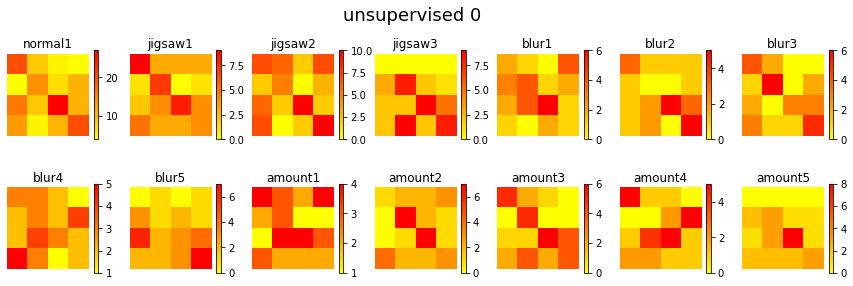

normal1 0.443 (165)
[[20.  5.  3.  7.]
 [ 6. 13.  7.  7.]
 [22.  4. 22.  7.]
 [10. 10.  5. 17.]]
jigsaw1 0.362 (51)
[[4. 3. 3. 4.]
 [0. 3. 1. 4.]
 [5. 3. 4. 4.]
 [1. 4. 1. 7.]]
jigsaw2 0.319 (65)
[[4. 1. 4. 8.]
 [1. 2. 3. 4.]
 [5. 4. 9. 1.]
 [6. 2. 4. 7.]]
jigsaw3 0.255 (48)
[[0. 0. 0. 0.]
 [0. 3. 3. 7.]
 [7. 3. 6. 0.]
 [4. 8. 4. 3.]]
blur1 0.396 (32)
[[4. 2. 0. 0.]
 [4. 2. 0. 2.]
 [1. 7. 5. 2.]
 [0. 0. 2. 1.]]
blur2 0.382 (24)
[[2. 1. 0. 1.]
 [0. 2. 1. 0.]
 [4. 2. 1. 2.]
 [2. 1. 3. 2.]]
blur3 0.31 (28)
[[4. 2. 1. 1.]
 [0. 1. 4. 1.]
 [1. 2. 3. 1.]
 [3. 1. 2. 1.]]
blur4 0.269 (35)
[[4. 3. 2. 0.]
 [3. 3. 2. 1.]
 [3. 1. 0. 3.]
 [2. 3. 2. 3.]]
blur5 0.202 (39)
[[0. 1. 1. 0.]
 [2. 3. 0. 1.]
 [7. 3. 4. 3.]
 [4. 7. 2. 1.]]
amount1 0.239 (34)
[[3. 2. 4. 4.]
 [3. 2. 1. 0.]
 [0. 4. 2. 2.]
 [5. 1. 0. 1.]]
amount2 0.243 (34)
[[2. 3. 1. 1.]
 [0. 3. 0. 5.]
 [4. 3. 1. 1.]
 [3. 3. 2. 2.]]
amount3 0.505 (29)
[[4. 3. 0. 0.]
 [0. 4. 0. 0.]
 [3. 1. 2. 2.]
 [3. 2. 3. 2.]]
amount4 0.451 (27)
[[4. 0. 1. 1.]


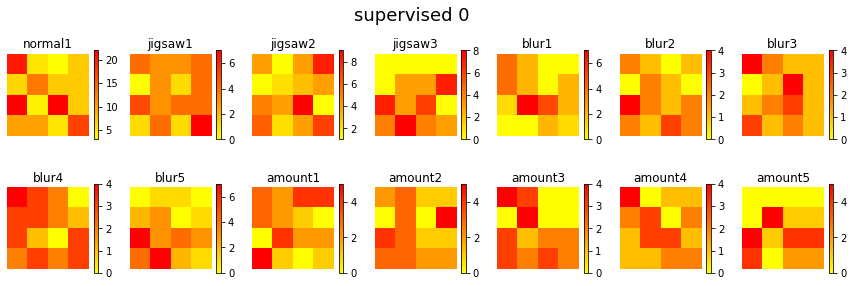

normal1 0.272 (48)
[[1. 3. 3. 2.]
 [2. 7. 3. 3.]
 [3. 3. 6. 3.]
 [3. 3. 2. 1.]]
jigsaw1 0.196 (27)
[[0. 4. 0. 0.]
 [1. 1. 0. 2.]
 [2. 2. 3. 2.]
 [6. 1. 1. 2.]]
jigsaw2 0.312 (15)
[[2. 2. 0. 2.]
 [0. 1. 1. 2.]
 [1. 0. 2. 0.]
 [1. 1. 0. 0.]]
jigsaw3 0.5 (12)
[[1. 2. 3. 0.]
 [0. 3. 0. 0.]
 [1. 0. 1. 1.]
 [0. 0. 0. 0.]]
blur1 0.425 (18)
[[1. 0. 0. 0.]
 [0. 4. 1. 3.]
 [2. 1. 1. 1.]
 [4. 0. 0. 0.]]
blur2 0.0 (7)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [2. 0. 0. 2.]
 [3. 0. 0. 0.]]
blur3 0.25 (9)
[[0. 1. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 1.]
 [2. 1. 1. 0.]]
blur4 0.0 (8)
[[0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [2. 0. 0. 3.]
 [1. 1. 0. 0.]]
blur5 0.083 (9)
[[0. 1. 0. 1.]
 [0. 0. 0. 2.]
 [1. 0. 1. 1.]
 [2. 0. 0. 0.]]
amount1 0.062 (11)
[[0. 1. 0. 2.]
 [0. 0. 0. 0.]
 [2. 0. 1. 1.]
 [2. 0. 2. 0.]]
amount2 0.1 (11)
[[0. 0. 0. 1.]
 [1. 2. 0. 2.]
 [1. 1. 0. 1.]
 [1. 1. 0. 0.]]
amount3 0.083 (8)
[[0. 1. 0. 0.]
 [1. 1. 1. 0.]
 [1. 1. 0. 1.]
 [0. 0. 1. 0.]]
amount4 0.0 (5)
[[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [1. 0. 0. 1.]
 [0

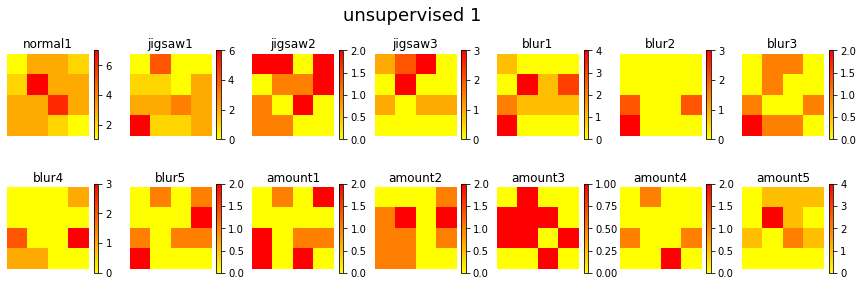

normal1 0.22 (38)
[[0. 3. 1. 3.]
 [0. 3. 1. 9.]
 [4. 2. 4. 1.]
 [2. 0. 3. 2.]]
jigsaw1 0.205 (21)
[[0. 1. 2. 0.]
 [0. 1. 0. 3.]
 [5. 0. 0. 2.]
 [1. 1. 1. 4.]]
jigsaw2 0.258 (13)
[[1. 1. 1. 2.]
 [2. 1. 0. 0.]
 [1. 0. 0. 2.]
 [0. 0. 1. 1.]]
jigsaw3 0.167 (10)
[[1. 1. 2. 2.]
 [0. 0. 1. 0.]
 [1. 1. 1. 0.]
 [0. 0. 0. 0.]]
blur1 0.35 (13)
[[0. 1. 0. 0.]
 [1. 2. 1. 1.]
 [2. 0. 0. 1.]
 [0. 0. 0. 4.]]
blur2 0.312 (7)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 0. 1. 2.]
 [0. 0. 0. 3.]]
blur3 0.25 (7)
[[1. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 1. 0. 0.]
 [1. 0. 0. 1.]]
blur4 0.25 (6)
[[1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [2. 0. 0. 1.]
 [1. 1. 0. 0.]]
blur5 0.458 (7)
[[0. 1. 0. 0.]
 [0. 1. 1. 0.]
 [2. 0. 1. 0.]
 [0. 0. 0. 1.]]
amount1 0.25 (9)
[[1. 1. 1. 0.]
 [0. 0. 0. 0.]
 [1. 1. 1. 0.]
 [0. 0. 2. 1.]]
amount2 0.271 (10)
[[0. 0. 1. 0.]
 [1. 1. 0. 2.]
 [1. 0. 1. 1.]
 [0. 0. 1. 1.]]
amount3 0.25 (8)
[[0. 1. 0. 0.]
 [0. 2. 0. 1.]
 [0. 1. 1. 1.]
 [1. 0. 0. 0.]]
amount4 0.0 (4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 1. 0. 0.]
 

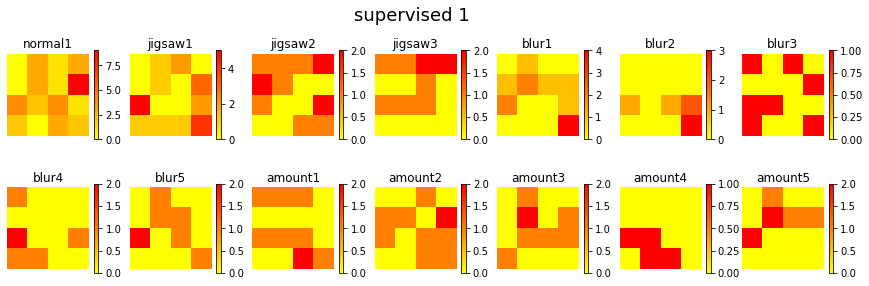

normal1 0.434 (216)
[[42.  8.  6.  8.]
 [ 8. 22.  8. 19.]
 [ 3. 10. 13. 12.]
 [14. 12. 11. 20.]]
jigsaw1 0.384 (91)
[[20.  4.  9.  1.]
 [ 4. 12.  4.  8.]
 [ 0.  7.  2.  3.]
 [ 1.  6.  4.  6.]]
jigsaw2 0.378 (76)
[[18.  2.  4.  6.]
 [ 3. 11.  2.  6.]
 [ 1.  3.  0.  3.]
 [ 2.  3.  5.  7.]]
jigsaw3 0.287 (50)
[[ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 4.  7.  4.  1.]
 [ 6.  8.  9. 11.]]
blur1 0.495 (35)
[[7. 1. 1. 2.]
 [0. 7. 1. 2.]
 [1. 1. 1. 2.]
 [1. 2. 2. 4.]]
blur2 0.413 (36)
[[12.  3.  1.  1.]
 [ 1.  3.  0.  2.]
 [ 0.  2.  0.  2.]
 [ 1.  2.  2.  4.]]
blur3 0.518 (45)
[[11.  1.  2.  3.]
 [ 1.  5.  2.  3.]
 [ 0.  4.  4.  2.]
 [ 0.  1.  2.  4.]]
blur4 0.47 (53)
[[7. 0. 2. 2.]
 [2. 8. 2. 6.]
 [3. 3. 3. 1.]
 [1. 3. 3. 7.]]
blur5 0.312 (39)
[[3. 3. 1. 2.]
 [0. 4. 2. 3.]
 [2. 4. 2. 1.]
 [3. 5. 1. 3.]]
amount1 0.617 (46)
[[13.  2.  1.  1.]
 [ 0. 12.  4.  2.]
 [ 0.  1.  3.  0.]
 [ 1.  3.  1.  2.]]
amount2 0.3 (42)
[[12.  3.  0.  1.]
 [ 2.  3.  4.  3.]
 [ 3.  1.  0.  0.]
 [ 5.  3.  0.  2.]]
amou

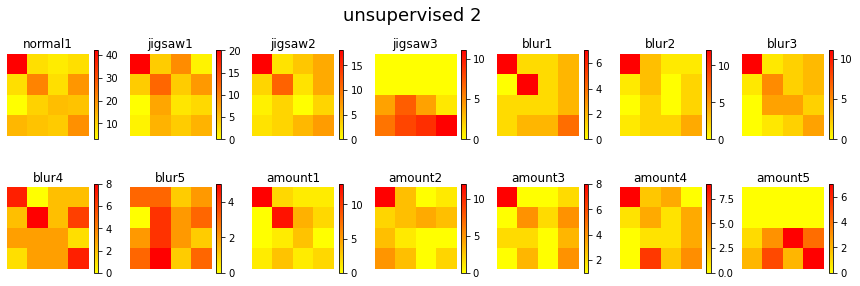

normal1 0.483 (188)
[[39.  5.  7.  7.]
 [ 8. 22.  9. 10.]
 [ 1. 10. 14.  6.]
 [11. 15.  6. 18.]]
jigsaw1 0.474 (86)
[[17.  1.  5.  6.]
 [ 4. 14.  4. 12.]
 [ 1.  2.  4.  1.]
 [ 2.  6.  1.  6.]]
jigsaw2 0.492 (69)
[[18.  6.  3.  1.]
 [ 0.  8.  6.  5.]
 [ 1.  2.  4.  0.]
 [ 1.  6.  3.  5.]]
jigsaw3 0.378 (43)
[[ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 1.  9.  5.  2.]
 [ 2.  7.  5. 12.]]
blur1 0.507 (38)
[[8. 0. 4. 2.]
 [0. 5. 0. 4.]
 [1. 0. 4. 0.]
 [2. 4. 3. 1.]]
blur2 0.458 (35)
[[8. 1. 1. 3.]
 [0. 3. 1. 1.]
 [0. 3. 1. 1.]
 [1. 6. 0. 5.]]
blur3 0.488 (45)
[[10.  2.  4.  2.]
 [ 1.  7.  0.  3.]
 [ 0.  2.  3.  2.]
 [ 0.  3.  3.  3.]]
blur4 0.312 (41)
[[4. 1. 1. 2.]
 [3. 3. 3. 2.]
 [0. 5. 1. 1.]
 [2. 5. 3. 5.]]
blur5 0.529 (36)
[[7. 0. 0. 1.]
 [1. 2. 0. 4.]
 [0. 5. 5. 1.]
 [0. 4. 1. 5.]]
amount1 0.412 (43)
[[8. 2. 2. 2.]
 [2. 7. 0. 8.]
 [0. 0. 1. 2.]
 [0. 2. 4. 3.]]
amount2 0.293 (39)
[[6. 2. 2. 3.]
 [4. 6. 1. 2.]
 [0. 3. 0. 2.]
 [0. 4. 2. 2.]]
amount3 0.494 (41)
[[9. 0. 5. 1.]
 [1. 4. 1. 2.]


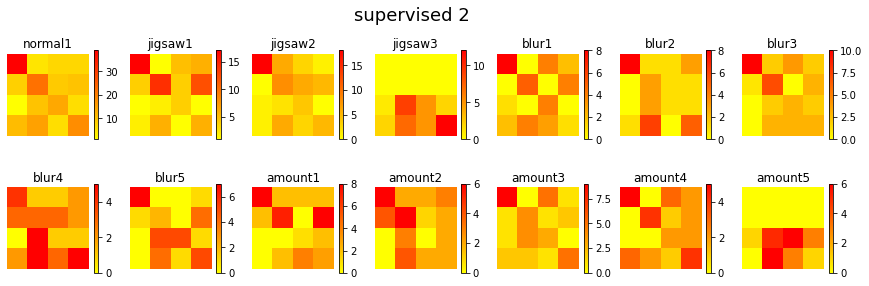

normal1 0.397 (82)
[[14.  1.  6.  5.]
 [ 4. 15.  6.  2.]
 [ 3.  4.  3.  6.]
 [ 3.  3.  3.  4.]]
jigsaw1 0.402 (23)
[[3. 1. 0. 7.]
 [0. 1. 0. 0.]
 [2. 2. 0. 1.]
 [1. 2. 1. 2.]]
jigsaw2 0.258 (35)
[[7. 2. 2. 3.]
 [4. 4. 1. 3.]
 [1. 1. 0. 2.]
 [2. 0. 2. 1.]]
jigsaw3 0.494 (27)
[[0. 0. 0. 0.]
 [0. 6. 2. 3.]
 [0. 0. 5. 2.]
 [1. 4. 2. 2.]]
blur1 0.368 (18)
[[2. 1. 0. 0.]
 [1. 5. 1. 2.]
 [1. 2. 1. 0.]
 [1. 0. 1. 0.]]
blur2 0.225 (11)
[[0. 1. 0. 0.]
 [0. 1. 0. 1.]
 [2. 0. 2. 1.]
 [0. 2. 1. 0.]]
blur3 0.42 (21)
[[3. 2. 1. 1.]
 [2. 4. 1. 1.]
 [0. 0. 1. 1.]
 [1. 1. 1. 1.]]
blur4 0.375 (15)
[[0. 1. 2. 0.]
 [1. 2. 0. 2.]
 [0. 0. 1. 1.]
 [0. 1. 1. 3.]]
blur5 0.282 (15)
[[3. 2. 1. 1.]
 [0. 1. 2. 2.]
 [0. 0. 0. 1.]
 [1. 0. 0. 1.]]
amount1 0.286 (18)
[[2. 0. 1. 1.]
 [2. 2. 0. 0.]
 [2. 2. 1. 2.]
 [1. 0. 2. 0.]]
amount2 0.521 (16)
[[3. 0. 0. 0.]
 [2. 3. 0. 1.]
 [2. 0. 1. 0.]
 [1. 2. 0. 1.]]
amount3 0.282 (20)
[[3. 1. 0. 3.]
 [0. 3. 2. 1.]
 [2. 0. 0. 0.]
 [0. 2. 2. 1.]]
amount4 0.625 (9)
[[1. 1. 0. 0.]
 [

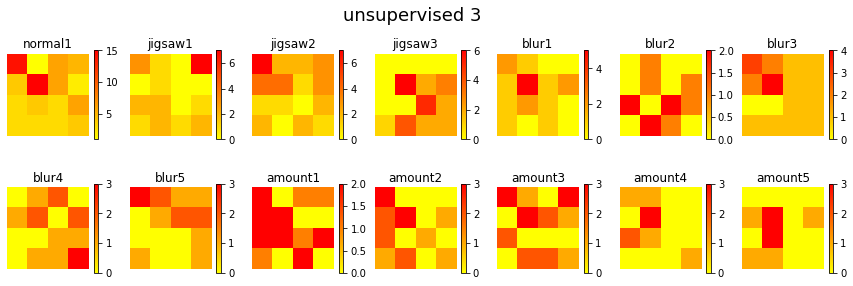

normal1 0.38 (67)
[[11.  2.  3.  2.]
 [ 2. 10.  6.  5.]
 [ 6.  2.  3.  4.]
 [ 2.  4.  2.  3.]]
jigsaw1 0.323 (23)
[[0. 2. 3. 2.]
 [2. 5. 0. 1.]
 [1. 0. 2. 0.]
 [1. 2. 2. 0.]]
jigsaw2 0.264 (30)
[[3. 3. 2. 4.]
 [1. 5. 1. 2.]
 [1. 0. 1. 2.]
 [1. 2. 2. 0.]]
jigsaw3 0.042 (15)
[[0. 0. 0. 0.]
 [2. 1. 1. 4.]
 [0. 1. 0. 0.]
 [4. 0. 2. 0.]]
blur1 0.333 (11)
[[0. 1. 0. 0.]
 [0. 4. 1. 1.]
 [0. 1. 2. 0.]
 [0. 1. 0. 0.]]
blur2 0.604 (16)
[[3. 0. 0. 1.]
 [0. 2. 1. 0.]
 [1. 0. 2. 0.]
 [3. 0. 1. 2.]]
blur3 0.237 (18)
[[1. 2. 1. 1.]
 [0. 3. 2. 1.]
 [2. 1. 1. 0.]
 [1. 1. 1. 0.]]
blur4 0.479 (15)
[[1. 2. 0. 1.]
 [0. 3. 1. 2.]
 [0. 0. 1. 1.]
 [1. 0. 0. 2.]]
blur5 0.437 (13)
[[2. 0. 0. 1.]
 [0. 3. 1. 0.]
 [0. 1. 0. 2.]
 [0. 1. 1. 1.]]
amount1 0.383 (13)
[[0. 0. 2. 0.]
 [0. 3. 0. 0.]
 [1. 1. 1. 2.]
 [0. 2. 0. 1.]]
amount2 0.196 (18)
[[2. 3. 2. 0.]
 [0. 1. 1. 2.]
 [1. 1. 1. 1.]
 [1. 1. 1. 0.]]
amount3 0.142 (16)
[[1. 0. 2. 3.]
 [1. 2. 1. 1.]
 [0. 1. 0. 3.]
 [1. 0. 0. 0.]]
amount4 0.385 (18)
[[5. 0. 2. 1.]
 

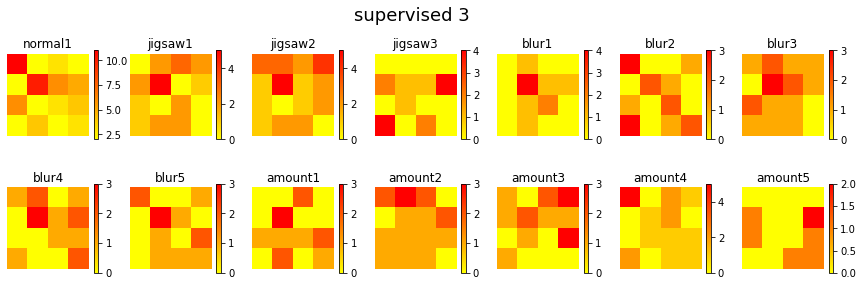

normal1 0.421 (175)
[[11. 13.  5.  7.]
 [ 8. 23.  8. 13.]
 [10.  8. 38.  7.]
 [ 3.  9.  4.  8.]]
jigsaw1 0.243 (56)
[[1. 2. 1. 1.]
 [4. 4. 4. 4.]
 [7. 4. 5. 5.]
 [4. 4. 2. 4.]]
jigsaw2 0.359 (55)
[[5. 0. 0. 4.]
 [3. 7. 1. 5.]
 [6. 2. 5. 5.]
 [1. 4. 5. 2.]]
jigsaw3 0.299 (51)
[[ 6.  3.  7.  7.]
 [ 4. 10.  4.  5.]
 [ 0.  0.  0.  0.]
 [ 2.  1.  1.  1.]]
blur1 0.323 (30)
[[2. 1. 1. 2.]
 [0. 2. 2. 1.]
 [1. 1. 3. 3.]
 [1. 4. 4. 2.]]
blur2 0.476 (31)
[[5. 3. 0. 2.]
 [1. 4. 1. 1.]
 [2. 2. 4. 0.]
 [0. 3. 1. 2.]]
blur3 0.344 (32)
[[2. 4. 0. 4.]
 [0. 5. 0. 3.]
 [0. 4. 3. 3.]
 [0. 2. 1. 1.]]
blur4 0.38 (38)
[[3. 0. 3. 4.]
 [2. 6. 2. 4.]
 [2. 1. 5. 0.]
 [3. 1. 1. 1.]]
blur5 0.275 (35)
[[1. 2. 1. 3.]
 [3. 4. 1. 2.]
 [4. 1. 3. 3.]
 [1. 3. 1. 2.]]
amount1 0.275 (34)
[[0. 1. 0. 2.]
 [1. 6. 0. 3.]
 [4. 4. 5. 1.]
 [1. 3. 2. 1.]]
amount2 0.343 (39)
[[1. 2. 1. 3.]
 [0. 5. 4. 2.]
 [4. 2. 6. 4.]
 [1. 1. 1. 2.]]
amount3 0.368 (37)
[[3. 1. 2. 3.]
 [2. 3. 4. 2.]
 [1. 3. 8. 1.]
 [3. 0. 0. 1.]]
amount4 0.246 (36)

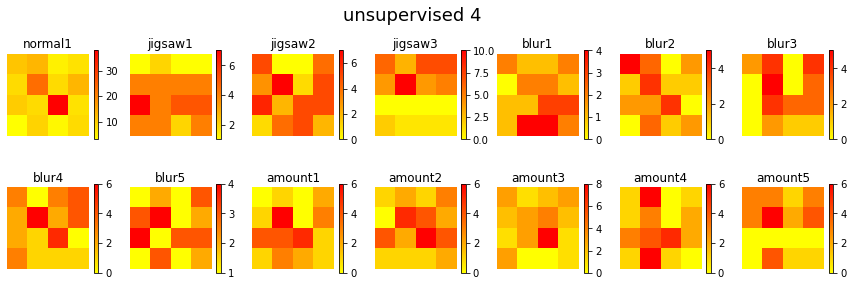

normal1 0.38 (172)
[[12.  6.  4. 11.]
 [ 6. 19.  7. 17.]
 [15. 11. 34.  7.]
 [ 4.  8.  5.  6.]]
jigsaw1 0.39 (58)
[[ 2.  4.  0.  2.]
 [ 3. 10.  1.  4.]
 [ 2.  2.  7.  8.]
 [ 3.  4.  1.  5.]]
jigsaw2 0.497 (62)
[[ 4.  3.  1.  3.]
 [ 1.  8.  0.  6.]
 [ 4.  3. 13.  2.]
 [ 0.  4.  3.  7.]]
jigsaw3 0.314 (48)
[[8. 6. 2. 4.]
 [5. 7. 6. 6.]
 [0. 0. 0. 0.]
 [0. 2. 1. 1.]]
blur1 0.472 (29)
[[4. 1. 1. 0.]
 [3. 2. 0. 1.]
 [0. 0. 8. 1.]
 [2. 6. 0. 0.]]
blur2 0.49 (29)
[[3. 3. 2. 1.]
 [2. 4. 0. 2.]
 [0. 1. 5. 2.]
 [1. 1. 0. 2.]]
blur3 0.439 (30)
[[6. 1. 0. 0.]
 [1. 4. 1. 2.]
 [1. 2. 4. 3.]
 [1. 4. 0. 0.]]
blur4 0.281 (38)
[[4. 5. 1. 0.]
 [2. 6. 1. 6.]
 [2. 1. 1. 1.]
 [3. 3. 1. 1.]]
blur5 0.382 (40)
[[4. 2. 2. 1.]
 [5. 4. 1. 3.]
 [3. 0. 4. 2.]
 [2. 2. 2. 3.]]
amount1 0.183 (33)
[[0. 3. 0. 2.]
 [2. 3. 2. 2.]
 [5. 3. 3. 2.]
 [1. 3. 1. 1.]]
amount2 0.356 (40)
[[4. 1. 2. 2.]
 [4. 5. 1. 1.]
 [1. 4. 5. 4.]
 [1. 2. 2. 1.]]
amount3 0.429 (37)
[[2. 2. 0. 3.]
 [2. 5. 2. 1.]
 [3. 1. 6. 4.]
 [0. 2. 1. 3.]]
amou

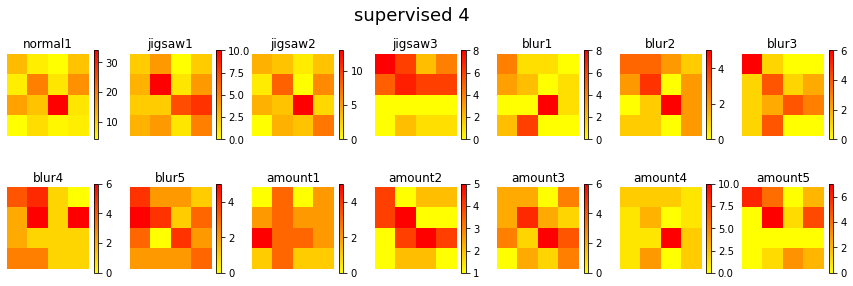

In [15]:
results_bar_plot = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}
std_lists = []
populations_raw = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}
populations_confmat_raw = {**{('unsupervised', _):[] for _ in range(5)},**{('supervised', _):[] for _ in range(5)}}

for rule in range(5):
    
    cond_dict = {'unsupervised':{'normal1':[],'jigsaw1':[],'jigsaw2':[],'jigsaw3':[],
                 'blur1':[],'blur2':[],'blur3':[],'blur4':[],'blur5':[],
                 'amount1':[], 'amount2':[],'amount3':[],'amount4':[],'amount5':[]},
                'supervised':{'normal1':[],'jigsaw1':[],'jigsaw2':[],'jigsaw3':[],
                 'blur1':[],'blur2':[],'blur3':[],'blur4':[],'blur5':[],
                 'amount1':[], 'amount2':[],'amount3':[],'amount4':[],'amount5':[]}}
#     cond_dict_for_std = deepcopy(cond_dict)
    
    for mode in ['unsupervised','supervised']:
        fig, axes = plt.subplots(2, 7,figsize=(15, 4.5))
        fb2id = {'fa1':0,'fb1':1,'fb3':2,'fc1':3}
        for k,v in cond_dict[mode].items():
            cond_dict[mode][k] = np.zeros((4,4))

        for raw_test in raw_test_list_by_rule[(mode,rule)]:
#         for raw_test in normal_high_performance_subject_by_rule[(mode,rule)]:
            
            raw_sample_pth = raw_test[1][-2]
            raw_sample_pth = randomized_names_reverse[raw_sample_pth].split('/')[-1]
            ans = raw_sample_pth.split('_')[2]
            rp = raw_test[2]
            rp = rand2fb[rp]
            if len(raw_sample_pth.split('_')) == 6:
                cond_dict[mode]['normal1'][fb2id[ans],fb2id[rp]] += 1
#                 cond_dict_for_std[mode]['normal1'].append(1 if ans==rp else 0)
            else:
                cond = raw_sample_pth.split('_')[6]
                cond_dict[mode][cond][fb2id[ans],fb2id[rp]] += 1
#                 cond_dict_for_std[mode][cond].append(1 if ans==rp else 0)

        for ii, (cond, conf_mat) in enumerate(cond_dict[mode].items()):
            if cond in ['amount5','jigsaw3']:
                indices = conf_entry_to_skip[rule]
                class_wise_acc_tmp = conf_mat.diagonal() / (conf_mat.sum(1)+1e-7)
                class_wise_acc = np.mean([class_wise_acc_tmp[i] for i in range(4) if i not in indices])
            else:
                class_wise_acc = (conf_mat.diagonal() / (conf_mat.sum(1)+1e-7)).mean()
            print(cond, round(class_wise_acc,3),'({})'.format(int(conf_mat.sum(1).sum())))
            results_bar_plot[(mode,rule)].append([cond, round(class_wise_acc,3),int(conf_mat.sum(1).sum())])
            print(conf_mat)
            if rule in [0,2,4]:
                populations_raw[(mode,rule)].append([cond, conf_mat.diagonal().sum(),conf_mat.sum()])
                populations_confmat_raw[(mode,rule)].append([cond,conf_mat])
            im = axes[ii//7, ii%7].imshow(conf_mat,cmap='autumn_r')
            fig.colorbar(im,shrink=0.8)
            axes[ii//7, ii%7].axis('off')
            axes[ii//7, ii%7].title.set_text(cond)
        plt.suptitle(mode+' '+str(rule), fontsize=18)

        plt.show()


In [16]:
def bootstrap_confmat(conf_mat,indices_to_skip=None):
    bootstrapped_classwise_accuracies = []
    for i in range(4): # bootstrap each class
        if indices_to_skip is not None and i in indices_to_skip:
            continue
        nCorrect, N = conf_mat[i,i], conf_mat[i].sum()
        population = [1]*int(nCorrect) + [0] * int(N-nCorrect)
        sampled = np.random.choice(population, size=int(N)//2,replace=False)
        bootstrapped_classwise_accuracies.append(sum(sampled)/len(sampled))
    return np.mean(bootstrapped_classwise_accuracies)

def bootstrap_human(mode,condition_id,cond_name,rules=[0,2,4],bootstrap_N=10000):
    
    bootstrapped_x = np.zeros((len(rules), bootstrap_N))
    for i, rule_no in enumerate(rules): # aggregate over 3 rules
        assert cond_name == populations_confmat_raw[(mode,rule_no)][condition_id][0]

        indices_to_skip = conf_entry_to_skip[rule_no] if cond_name in  ['amount5','jigsaw3'] else None
        conf_mat_x = populations_confmat_raw[(mode,rule_no)][condition_id][1]
        bootstrapped_x_tmp = [bootstrap_confmat(conf_mat_x,indices_to_skip) for _ in range(bootstrap_N)]
        bootstrapped_x[i] = bootstrapped_x_tmp
    bootstrapped_x = bootstrapped_x.mean(0) 
    return bootstrapped_x

def bootstrap(nCorrect, N):
    population = [1]*int(nCorrect) + [0] * int(N-nCorrect)
#     print(population, int(N)//2)
    sampled = np.random.choice(population , size=int(N)//2,replace=False)
    return sum(sampled)/len(sampled)
    

In [17]:
populations_confmat_raw

{('unsupervised',
  0): [['normal1', array([[20.,  9.,  5.,  4.],
          [ 4., 14.,  7., 11.],
          [16.,  9., 27., 11.],
          [13.,  5., 11., 20.]])], ['jigsaw1',
   array([[9., 3., 3., 3.],
          [1., 7., 0., 1.],
          [2., 4., 8., 4.],
          [5., 3., 3., 4.]])], ['jigsaw2',
   array([[ 7.,  6.,  2.,  7.],
          [ 2.,  5.,  0.,  3.],
          [ 6.,  2., 10.,  2.],
          [ 7.,  0.,  2., 10.]])], ['jigsaw3',
   array([[0., 0., 0., 0.],
          [3., 8., 2., 1.],
          [2., 2., 9., 5.],
          [2., 9., 2., 8.]])], ['blur1',
   array([[2., 1., 0., 4.],
          [3., 4., 1., 2.],
          [2., 4., 6., 1.],
          [1., 0., 2., 1.]])], ['blur2',
   array([[3., 1., 1., 1.],
          [1., 0., 0., 1.],
          [1., 2., 5., 3.],
          [1., 2., 0., 5.]])], ['blur3',
   array([[4., 2., 0., 0.],
          [1., 6., 0., 2.],
          [2., 0., 3., 3.],
          [3., 1., 1., 5.]])], ['blur4',
   array([[3., 3., 2., 1.],
          [2., 3., 2., 4.

In [16]:
human_unsup_acc = {'normal': 0.43134662045060657, 'jigsaw1': 0.378608695652174, 'jigsaw2': 0.402, 'jigsaw3': 0.3587727272727273, 'blur1': 0.3927373737373737, 'blur2': 0.42860638297872344, 'blur3': 0.4775818181818182, 'blur4': 0.3795488721804511, 'blur5': 0.26616964285714284, 'amount1': 0.4212809917355372, 'amount2': 0.36805882352941177, 'amount3': 0.45939473684210524, 'amount4': 0.32196261682242994, 'amount5': 0.3987032967032967}
human_sup_acc = {'normal': 0.43668380952380953, 'jigsaw1': 0.4197230769230769, 'jigsaw2': 0.4362091836734694, 'jigsaw3': 0.3134244604316547, 'blur1': 0.4608686868686869, 'blur2': 0.44781818181818184, 'blur3': 0.4253398058252427, 'blur4': 0.2884649122807018, 'blur5': 0.36697391304347826, 'amount1': 0.2898272727272727, 'amount2': 0.3002566371681416, 'amount3': 0.4745046728971962, 'amount4': 0.4725604395604396, 'amount5': 0.3824705882352941}

In [18]:
# populations
populations = {}
populations_by_rule = {}
for (mode,rule), conditions in populations_raw.items():
    for (cond, nCorrect, N) in conditions:
        if (mode, cond) not in populations:
            populations[(mode, cond)] = [0,0]
        populations[(mode, cond)][0] += nCorrect
        populations[(mode, cond)][1] += N
        
        if (mode, rule, cond) not in populations_by_rule:
            populations_by_rule[(mode, rule, cond) ] = [0,0]
        populations_by_rule[(mode, rule, cond)][0] += nCorrect
        populations_by_rule[(mode, rule, cond)][1] += N


## human all conditions under both modes vs chance

In [63]:
for mode in ['unsupervised','supervised']:
    for i, cond in enumerate(COND_LIST):
        sampled_list = bootstrap_human(mode,i,cond)
        N = populations[(mode,cond)][1]
        chance_list = np.array([bootstrap(int(0.25*N), N)  for i in range(10000)])
        print((mode,cond),statsmodels.stats.weightstats.ttest_ind(sampled_list,chance_list),statsmodels.stats.weightstats.ttest_ind(sampled_list,chance_list,alternative='larger')[1]) 

('unsupervised', 'normal1') (646.0489599999826, 0.0, 19998.0) 0.0
('unsupervised', 'jigsaw1') (265.60536309111313, 0.0, 19998.0) 0.0
('unsupervised', 'jigsaw2') (325.76068825310546, 0.0, 19998.0) 0.0
('unsupervised', 'jigsaw3') (190.82275903938523, 0.0, 19998.0) 0.0
('unsupervised', 'blur1') (200.83337207991823, 0.0, 19998.0) 0.0
('unsupervised', 'blur2') (271.40999623706114, 0.0, 19998.0) 0.0
('unsupervised', 'blur3') (336.57184421561857, 0.0, 19998.0) 0.0
('unsupervised', 'blur4') (212.43558641015892, 0.0, 19998.0) 0.0
('unsupervised', 'blur5') (25.108908401104554, 5.245427013157506e-137, 19998.0) 2.622713506578753e-137
('unsupervised', 'amount1') (251.4740905764779, 0.0, 19998.0) 0.0
('unsupervised', 'amount2') (207.57011187027675, 0.0, 19998.0) 0.0
('unsupervised', 'amount3') (346.2425108595498, 0.0, 19998.0) 0.0
('unsupervised', 'amount4') (122.08540045915524, 0.0, 19998.0) 0.0
('unsupervised', 'amount5') (214.52605649718058, 0.0, 19998.0) 0.0
('supervised', 'normal1') (628.665318

## Human: supervised vs unsupervised normal condition

In [19]:

unsup_norm_list = bootstrap_human('unsupervised',COND_DICT['normal1'],'normal1')  
sup_norm_list = bootstrap_human('supervised',COND_DICT['normal1'],'normal1') 
# differences = [unsup_norm_list[i]-sup_norm_list[i] for i in range(100000)]
# differences = [sup_norm_list[i]-unsup_norm_list[i] for i in range(10000)]
# 
print(statsmodels.stats.weightstats.ttest_ind(sup_norm_list,unsup_norm_list))
# print(scipy.stats.ttest_1samp(differences,0.0,alternative='greater'))


(12.19482974098891, 4.3769124471528145e-34, 19998.0)


## Human: supervised vs unsupervised blur=1,2

In [71]:
cond, cond_i = 'blur1', COND_DICT['blur1']
x =  bootstrap_human('unsupervised',cond_i,cond)
y =  bootstrap_human('supervised',cond_i,cond)
print(cond,statsmodels.stats.weightstats.ttest_ind(y,x),statsmodels.stats.weightstats.ttest_ind(y,x,alternative='larger')[1])

cond, cond_i = 'blur2', COND_DICT['blur2']
x =  bootstrap_human('unsupervised',cond_i,cond)
y =  bootstrap_human('supervised',cond_i,cond)
print(cond,statsmodels.stats.weightstats.ttest_ind(y,x),statsmodels.stats.weightstats.ttest_ind(y,x,alternative='larger')[1])



blur1 (81.33298128426958, 0.0, 19998.0) 0.0
blur2 (17.726520953814525, 8.949095678620252e-70, 19998.0) 4.474547839310126e-70


## Human: supervised vs unsupervised blur=3,4

In [69]:
cond, cond_i = 'blur3', COND_DICT['blur3']
x =  bootstrap_human('unsupervised',cond_i,cond)
y =  bootstrap_human('supervised',cond_i,cond)
print(cond,statsmodels.stats.weightstats.ttest_ind(x,y),statsmodels.stats.weightstats.ttest_ind(x,y,alternative='larger')[1])

cond, cond_i = 'blur4', COND_DICT['blur4']
x =  bootstrap_human('unsupervised',cond_i,cond)
y =  bootstrap_human('supervised',cond_i,cond)
print(cond,statsmodels.stats.weightstats.ttest_ind(x,y),statsmodels.stats.weightstats.ttest_ind(x,y,alternative='larger')[1])



blur3 (82.24583772247594, 0.0, 19998.0) 0.0
blur4 (127.33674542320543, 0.0, 19998.0) 0.0


## Human: supervised vs unsupervised blur=5

In [72]:
cond, cond_i = 'blur5', COND_DICT['blur5']
x =  bootstrap_human('unsupervised',cond_i,cond)
y =  bootstrap_human('supervised',cond_i,cond)
print(cond,statsmodels.stats.weightstats.ttest_ind(y,x),statsmodels.stats.weightstats.ttest_ind(y,x,alternative='larger')[1])


blur5 (160.79551506922832, 0.0, 19998.0) 0.0


In [74]:
cond_x, cond_i_x = 'blur3', COND_DICT['blur3']
cond_y, cond_i_y = 'normal1', COND_DICT['normal1']
x =  bootstrap_human('unsupervised',cond_i_x,cond_x)
y =  bootstrap_human('unsupervised',cond_i_y,cond_y)
print(cond_x,cond_y,statsmodels.stats.weightstats.ttest_ind(x,y),statsmodels.stats.weightstats.ttest_ind(x,y,alternative='larger')[1])

cond_x, cond_i_x = 'blur1', COND_DICT['blur1']
cond_y, cond_i_y = 'normal1', COND_DICT['normal1']
x =  bootstrap_human('supervised',cond_i_x,cond_x)
y =  bootstrap_human('supervised',cond_i_y,cond_y)
print(cond_x,cond_y,statsmodels.stats.weightstats.ttest_ind(x,y),statsmodels.stats.weightstats.ttest_ind(x,y,alternative='larger')[1])


blur3 normal1 (71.2372813778845, 0.0, 19998.0) 0.0
blur1 normal1 (35.40544759146161, 2.251791673438499e-266, 19998.0) 1.1258958367192496e-266


In [19]:
# from mpmath import mp
# t = mp.mpf(18)
# nu = mp.mpf(10000)
# x2 = nu / (t**2 + nu)
# p = mp.betainc(nu/2, mp.one/2, x2=x2, regularized=True)
# print(p)

# Get model data

In [19]:
model_avg_results = {'vicreg': {'normal': 0.4401866004783911,
  'jigsaw1': 0.31093012859648655,
  'jigsaw2': 0.2791020831337299,
  'jigsaw3': 0.3110024449184554,
  'blur1': 0.43740628334630915,
  'blur2': 0.4260708226434637,
  'blur3': 0.39455050083817444,
  'blur4': 0.27860096676434376,
  'blur5': 0.22520135690768558,
  'amount1': 0.3415080679034045,
  'amount2': 0.3665093187308648,
  'amount3': 0.433968617472675,
  'amount4': 0.4505245886818958,
  'amount5': 0.505734968043509},
 'seco': {'normal': 0.48412211858285426,
  'jigsaw1': 0.38842955388960954,
  'jigsaw2': 0.3186125438501183,
  'jigsaw3': 0.25476411535407845,
  'blur1': 0.4621134861542361,
  'blur2': 0.4550601787318547,
  'blur3': 0.3691499112580251,
  'blur4': 0.27353622667727623,
  'blur5': 0.2808759957188513,
  'amount1': 0.389538192754972,
  'amount2': 0.42234860713973327,
  'amount3': 0.4571549980781213,
  'amount4': 0.4762651013570891,
  'amount5': 0.4883054590509051},
 'dino': {'normal': 0.3746268677026518,
  'jigsaw1': 0.28801229342690227,
  'jigsaw2': 0.252871688983358,
  'jigsaw3': 0.28344074726929713,
  'blur1': 0.372820252412137,
  'blur2': 0.3757950509385914,
  'blur3': 0.35746806156087435,
  'blur4': 0.2940496788645569,
  'blur5': 0.24658524939199775,
  'amount1': 0.3262764414240738,
  'amount2': 0.33632505349363206,
  'amount3': 0.36854035968682236,
  'amount4': 0.3818766825959095,
  'amount5': 0.43615215205010915},
 'orl': {'normal': 0.4744793248139438,
  'jigsaw1': 0.37631014577342853,
  'jigsaw2': 0.30941806875827305,
  'jigsaw3': 0.21632982124042757,
  'blur1': 0.4727190121561168,
  'blur2': 0.47375437351124894,
  'blur3': 0.43057578960453463,
  'blur4': 0.27969024272118476,
  'blur5': 0.2298314091696487,
  'amount1': 0.3341450526804743,
  'amount2': 0.37514201531683183,
  'amount3': 0.43262223699737334,
  'amount4': 0.4671514182062665,
  'amount5': 0.48558087754817236},
 'supervised': {'normal': 0.3747792166846976,
  'jigsaw1': 0.30747663492949906,
  'jigsaw2': 0.27544535796006775,
  'jigsaw3': 0.2461176925997283,
  'blur1': 0.3609468263165311,
  'blur2': 0.3643166545119011,
  'blur3': 0.3204835800438489,
  'blur4': 0.2548809454889966,
  'blur5': 0.2545223294537726,
  'amount1': 0.3400145091726156,
  'amount2': 0.3727291763255336,
  'amount3': 0.38368482761353756,
  'amount4': 0.3995204243756159,
  'amount5': 0.4309057721637544},
 'simclr': {'normal': 0.3535617757891651,
  'jigsaw1': 0.3046427601767113,
  'jigsaw2': 0.27802763315198936,
  'jigsaw3': 0.2640969165898387,
  'blur1': 0.3573063105489796,
  'blur2': 0.3596408707483343,
  'blur3': 0.3351399652748023,
  'blur4': 0.23698229567576323,
  'blur5': 0.2392795060526549,
  'amount1': 0.35987498724531986,
  'amount2': 0.41118373941460556,
  'amount3': 0.437256440496662,
  'amount4': 0.43625255579336064,
  'amount5': 0.44112004785310654},
 'simsiam': {'normal': 0.4633043757016041,
  'jigsaw1': 0.3182310001663674,
  'jigsaw2': 0.3107120486034711,
  'jigsaw3': 0.17322378068938937,
  'blur1': 0.46464936127047757,
  'blur2': 0.46257810715282927,
  'blur3': 0.44456250472357267,
  'blur4': 0.28502521735332426,
  'blur5': 0.21358160255401112,
  'amount1': 0.34651611569874774,
  'amount2': 0.3995714971628702,
  'amount3': 0.45899380210180196,
  'amount4': 0.48014041073717034,
  'amount5': 0.49627028749102636},
 'context_encoder': {'normal': 0.2606684650030463,
  'jigsaw1': 0.26523291513352526,
  'jigsaw2': 0.2588633758618239,
  'jigsaw3': 0.14674727413953725,
  'blur1': 0.254215381852225,
  'blur2': 0.26184294555199583,
  'blur3': 0.27141904357632207,
  'blur4': 0.2609168364266497,
  'blur5': 0.2449833773863994,
  'amount1': 0.29237366387706076,
  'amount2': 0.289836779067967,
  'amount3': 0.30533276864497655,
  'amount4': 0.31103244968486304,
  'amount5': 0.20098464733787946},
 'human_sup': {'normal': 0.43668380952380953,
  'jigsaw1': 0.4197230769230769,
  'jigsaw2': 0.4362091836734694,
  'jigsaw3': 0.3134244604316547,
  'blur1': 0.4608686868686869,
  'blur2': 0.44781818181818184,
  'blur3': 0.4253398058252427,
  'blur4': 0.2884649122807018,
  'blur5': 0.36697391304347826,
  'amount1': 0.2898272727272727,
  'amount2': 0.3002566371681416,
  'amount3': 0.4745046728971962,
  'amount4': 0.4725604395604396,
  'amount5': 0.3824705882352941},
 'human_unsup': {'normal': 0.43134662045060657,
  'jigsaw1': 0.378608695652174,
  'jigsaw2': 0.402,
  'jigsaw3': 0.3587727272727273,
  'blur1': 0.3927373737373737,
  'blur2': 0.42860638297872344,
  'blur3': 0.4775818181818182,
  'blur4': 0.3795488721804511,
  'blur5': 0.26616964285714284,
  'amount1': 0.4212809917355372,
  'amount2': 0.36805882352941177,
  'amount3': 0.45939473684210524,
  'amount4': 0.32196261682242994,
  'amount5': 0.3987032967032967}}

In [20]:
gt, pred

NameError: name 'gt' is not defined

In [21]:
root = '/home/liuxiao/ContextReasoning/fribble_exp_0shot_logs/multiruns'
model_names = ['vicreg', 'seco', 'dino', 'orl', 'supervised','simclr','simsiam','context_encoder']
model_results_all_rules = []
model_error_bars_all = {k: {} for k in model_names}
model_error_cnt = {k: {} for k in model_names}
model_error_cnt_by_rule = {k: {_:{} for _ in [0,2,4]} for k in model_names}
model_confmat_by_rule = {k: {_:{} for _ in [0,2,4]} for k in model_names}

for rule_no in [0,2,4]:
    model_results = {}
    for model in model_names:
        if model in ['orl']:
            runs = [0,1,3]
        else:
            runs = [0,2,4]
        model_results[model] = {}
        for run_no in runs:
            with open('{}/{}/{}_{}.pkl'.format(root,model,rule_no,run_no),'rb') as f:
                results_tmp = pkl.load(f)
            
            for entry in results_tmp[0].split('\t'):
                cond, acc1 = entry.split(':')[0], float(entry.split(':')[1].strip())
                cond = cond.replace('normal1','normal')
#                 print(model,rule_no,run_no,cond,acc1)
                model_results[model][cond] =  model_results[model].get(cond, 0) + acc1 * (1/3)
            for pth, pred in results_tmp[1].items():
                gt = {'fa1':0,'fb1':1,'fb3':2,'fc1':3}[pth.split('/')[0].split('_')[1]]
                tmp = pth.split('/')[2].split('_') 
                cond = tmp[-1] if len(tmp) == 7 else 'normal'
                model_error_cnt[model].setdefault(cond,[]).append(1 if gt == pred else 0)
                model_error_cnt_by_rule[model][rule_no].setdefault(cond,[]).append(1 if gt == pred else 0)
                if cond not in model_confmat_by_rule[model][rule_no]:
                    model_confmat_by_rule[model][rule_no][cond] = np.zeros((4,4))
                model_confmat_by_rule[model][rule_no][cond][gt,pred] += 1
                
                
    model_results_all_rules.append(model_results)  
    print(model_results)
for m,_ in model_error_cnt.items():
    for k,v in _.items():
        model_error_bars_all[m][k] = np.std(v)/(len(v)**0.5)
        
model_error_bars_all['human_sup']={'normal': 0.02171030715033591,
  'jigsaw1': 0.03540757147280004,
  'jigsaw2': 0.03556335992398089,
  'jigsaw3': 0.03968697369379464,
  'blur1': 0.049940730552832754,
  'blur2': 0.052802294163896875,
  'blur3': 0.048984706091023796,
  'blur4': 0.0432006509476255,
  'blur5': 0.0448992735869577,
  'amount1': 0.04406129191852727,
  'amount2': 0.0441458611460336,
  'amount3': 0.048165532968335374,
  'amount4': 0.05238575153192088,
  'amount5': 0.05286037663383562}
model_error_bars_all['human_unsup'] = {'normal': 0.02069862396773713,
  'jigsaw1': 0.03399432440330523,
  'jigsaw2': 0.03484026842250229,
  'jigsaw3': 0.03890829622809868,
  'blur1': 0.049505463756652664,
  'blur2': 0.05157106231293967,
  'blur3': 0.04764159961130258,
  'blur4': 0.042161354302586274,
  'blur5': 0.0430768047335171,
  'amount1': 0.04526632706654265,
  'amount2': 0.045115587579257106,
  'amount3': 0.046648774563061136,
  'amount4': 0.045980555685499344,
  'amount5': 0.0516972741548122}

{'vicreg': {'normal': 0.40005034208297724, 'jigsaw1': 0.3062765896320343, 'jigsaw2': 0.26358412702878314, 'jigsaw3': 0.3270508348941803, 'blur1': 0.40984765688578284, 'blur2': 0.38888203104337055, 'blur3': 0.3844927450021108, 'blur4': 0.25650117794672644, 'blur5': 0.21278498073418933, 'amount1': 0.2700340151786804, 'amount2': 0.26134955883026123, 'amount3': 0.36433519919713336, 'amount4': 0.3631538152694702, 'amount5': 0.4219661056995392}, 'seco': {'normal': 0.43577038248380023, 'jigsaw1': 0.3548093239466349, 'jigsaw2': 0.3301205237706502, 'jigsaw3': 0.34987606604894, 'blur1': 0.4215601086616516, 'blur2': 0.4083225826422373, 'blur3': 0.38935961325963336, 'blur4': 0.3030960261821747, 'blur5': 0.2957248389720917, 'amount1': 0.34236909945805866, 'amount2': 0.37231493989626563, 'amount3': 0.3417636652787526, 'amount4': 0.3948477109273274, 'amount5': 0.41399658719698584}, 'dino': {'normal': 0.3473552266756693, 'jigsaw1': 0.30655327439308167, 'jigsaw2': 0.26654939850171405, 'jigsaw3': 0.3363

In [88]:
results_tmp[1]

{'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/16.png': 1,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/4.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/10.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/8.png': 3,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/5.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/11.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/7.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/6.png': 3,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/9.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/1.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/3.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_4_0_amount1/15.png': 3,
 'pillow_fb3/test/1_fribble_fb3_3213_7_20/18.png': 1,
 'pillow_fb3/test/1_fribble_fb3_3213_7_20/4.png': 1,
 'pillow_fb3/test/1_fribble_fb3_3213_7_20/20.png': 1,
 'pillow_fb3/test/1_fribble_fb3_3213_7_20/10.png': 2,
 'pillow_fb3/test/1_fribble_fb3_3213_7_20/2.png': 1,
 'pillow

In [22]:

def bootstrap_model(model,cond,rules=[0,2,4],bootstrap_N=10000):
    bootstrapped_x = np.zeros((len(rules), bootstrap_N))
    for i, rule_no in enumerate(rules): # aggregate over 3 rules
        conf_mat_x = model_confmat_by_rule[model][rule_no][cond]
        indices_to_skip = conf_entry_to_skip[rule_no] if cond in  ['amount5','jigsaw3'] else None

        bootstrapped_x_tmp = [bootstrap_confmat(conf_mat_x,indices_to_skip) for _ in range(bootstrap_N)]
        bootstrapped_x[i] = bootstrapped_x_tmp
    bootstrapped_x = bootstrapped_x.mean(0) 
    return bootstrapped_x    


## all methods all conditions compared to chance

In [54]:
for model in model_confmat_by_rule.keys():
    for cond in COND_LIST:
        if cond == 'normal1':
            cond = 'normal'
        sampled_list = bootstrap_model(model,cond)
        chance_list = np.array([bootstrap(int(0.25*N), N) for i in range(10000)])
        print(model, cond, statsmodels.stats.weightstats.ttest_ind(sampled_list,chance_list))        

vicreg normal (271.5728813728979, 0.0, 19998.0)
vicreg jigsaw1 (110.47010820001422, 0.0, 19998.0)
vicreg jigsaw2 (69.20085050842502, 0.0, 19998.0)
vicreg jigsaw3 (94.98680049543114, 0.0, 19998.0)
vicreg blur1 (275.9670315966498, 0.0, 19998.0)
vicreg blur2 (253.29639827189544, 0.0, 19998.0)
vicreg blur3 (213.27298247412148, 0.0, 19998.0)
vicreg blur4 (67.7210561394353, 0.0, 19998.0)
vicreg blur5 (-2.8054632224359333, 0.00502928290036153, 19998.0)
vicreg amount1 (153.01573197999124, 0.0, 19998.0)
vicreg amount2 (183.1040221587781, 0.0, 19998.0)
vicreg amount3 (266.0605518887109, 0.0, 19998.0)
vicreg amount4 (290.81871316216564, 0.0, 19998.0)
vicreg amount5 (375.4644959629047, 0.0, 19998.0)
seco normal (329.7020828009369, 0.0, 19998.0)
seco jigsaw1 (207.10849029402291, 0.0, 19998.0)
seco jigsaw2 (117.8935064576121, 0.0, 19998.0)
seco jigsaw3 (12.670722706225524, 1.1885489052946055e-36, 19998.0)
seco blur1 (303.3924159988433, 0.0, 19998.0)
seco blur2 (290.29582286971714, 0.0, 19998.0)
seco

## compare SeCo, ORL, SimSiam, VICReg to unsupervised humans

In [46]:
unsup_norm_list = bootstrap_human('unsupervised',COND_DICT['normal1'],'normal1')  
cond = 'normal'
for model in ['seco','orl','simsiam','vicreg']:
    sampled_list = bootstrap_model(model,cond) 
    
    print(model, cond, statsmodels.stats.weightstats.ttest_ind(sampled_list,unsup_norm_list))
     


seco normal (248.8130326776258, 0.0, 19998.0)
orl normal (205.39631433250918, 0.0, 19998.0)
simsiam normal (153.12340320590997, 0.0, 19998.0)
vicreg normal (50.143348125710624, 0.0, 19998.0)


In [31]:
for model in ['seco','orl','simsiam','vicreg']:
    print(model, 
          (model_avg_results[model]['normal'] - model_avg_results['human_unsup']['normal'])*100,
          ((model_error_bars_all[model]['normal']*100)**2 + (model_error_bars_all[('human_unsup')]['normal']*100)**2)**0.5)


seco 5.277549813224769 2.171790558518246
orl 4.313270436333721 2.171475919344736
simsiam 3.1957755250997533 2.1709176541286657
vicreg 0.8839980027784522 2.170004061586235


## compare SeCo, ORL, SimSiam, VICReg to supervised imagenet

In [47]:
# model_error_cnt['vicreg'].keys()
# unsup_norm = populations[('unsupervised', 'normal1')]
# unsup_norm_list = [bootstrap(int(unsup_norm[0]), int(unsup_norm[1]))  for i in range(10000)]
# differences = [unsup_norm_list[i]-sup_norm_list[i] for i in range(100000)]
supervised_list = bootstrap_model('supervised','normal') 

cond = 'normal'
for model in ['seco','orl','simsiam','vicreg']:
    sampled_list = bootstrap_model(model,cond) 
    
    print(model, cond, statsmodels.stats.weightstats.ttest_ind(sampled_list,unsup_norm_list))
     


seco normal (247.90911421490452, 0.0, 19998.0)
orl normal (205.55652339345642, 0.0, 19998.0)
simsiam normal (153.1205966239378, 0.0, 19998.0)
vicreg normal (50.339490841724874, 0.0, 19998.0)


In [34]:
for model in ['seco','orl','simsiam','vicreg']:
    print(model, 
          (model_avg_results[model]['normal'] - model_avg_results['supervised']['normal'])*100,
          ((model_error_bars_all[model]['normal']*100)**2 + (model_error_bars_all[('supervised')]['normal']*100)**2)**0.5)


seco 10.934290189815666 0.913565518206333
orl 9.970010812924619 0.9128172841706484
simsiam 8.85251590169065 0.91148844589173
vicreg 6.5407383793693485 0.9093103723632362


## compare SeCo to unsupervised/sup humans

In [48]:
unsup_norm_list = bootstrap_human('unsupervised',COND_DICT['normal1'],'normal1')  
sup_norm_list = bootstrap_human('supervised',COND_DICT['normal1'],'normal1')  
seco_list = bootstrap_model('seco','normal') 

for _ in [unsup_norm_list,sup_norm_list]:
    print(statsmodels.stats.weightstats.ttest_ind(seco_list,_))
        
for model in ['human_sup','human_unsup']:
    print(model, 
          (model_avg_results['seco']['normal'] - model_avg_results[model]['normal'])*100,
          ((model_error_bars_all['seco']['normal']*100)**2 + (model_error_bars_all[(model)]['normal']*100)**2)**0.5)


(248.53932225285564, 0.0, 19998.0)
(213.5262827484208, 0.0, 19998.0)
human_sup 4.743830905904472 2.2684175660822326
human_unsup 5.277549813224769 2.171790558518246


# Blur

### ANOVA for all models & humans 

In [67]:
for mode in ['unsupervised','supervised']:
    groups=[bootstrap_human(mode,COND_DICT['normal1'],'normal1')]
    for cond in ['blur{}'.format(_) for _ in range(1,6)]:
        groups += [bootstrap_human(mode,COND_DICT[cond],cond)]
    print('='*10)
    print(mode, statsmodels.stats.oneway.anova_oneway(groups))

unsupervised statistic = 26755.634641113702
pvalue = 0.0
df = (5.0, 26979.975294883254)
df_num = 5.0
df_denom = 26979.975294883254
nobs_t = 60000.0
n_groups = 6
means = [0.43077648 0.38838792 0.42826125 0.47130306 0.37089396 0.26618113]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [0.00044848 0.00353427 0.00267968 0.0027534  0.00201097 0.00204081]
use_var = unequal
welch_correction = True
tuple = (26755.634641113702, 0.0)
supervised statistic = 18661.866546290174
pvalue = 0.0
df = (5.0, 27004.49052446932)
df_num = 5.0
df_denom = 27004.49052446932
nobs_t = 60000.0
n_groups = 6
means = [0.43555348 0.45755851 0.443475   0.41218185 0.28797391 0.37114979]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [0.00053159 0.00383063 0.00511986 0.00257555 0.00225181 0.00220669]
use_var = unequal
welch_correction = True
tuple = (18661.866546290174, 0.0)


In [69]:
for model in model_confmat_by_rule.keys():
    groups=[bootstrap_model(model,'normal')]
    for cond in ['blur{}'.format(_) for _ in range(1,6)]:
        groups += [ bootstrap_model(model,cond)]
    print('='*10)
    print(model, statsmodels.stats.oneway.anova_oneway(groups))

vicreg statistic = 3319992.2438322115
pvalue = 0.0
df = (5.0, 27952.882939074818)
df_num = 5.0
df_denom = 27952.882939074818
nobs_t = 60000.0
n_groups = 6
means = [0.44185295 0.44240566 0.42659012 0.39417809 0.27843668 0.22417231]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [3.19203442e-05 3.67368296e-05 3.56035059e-05 2.93786719e-05
     2.31722639e-05 2.22477958e-05]
use_var = unequal
welch_correction = True
tuple = (3319992.2438322115, 0.0)
seco statistic = 3898781.083781227
pvalue = 0.0
df = (5.0, 27692.752088557176)
df_num = 5.0
df_denom = 27692.752088557176
nobs_t = 60000.0
n_groups = 6
means = [0.48554188 0.46479109 0.45532934 0.3690574  0.273795   0.28048339]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [3.47097402e-05 4.18107361e-05 4.05454733e-05 2.49552271e-05
     1.14654466e-05 1.53143976e-05]
use_var = unequal
welch_correction = True
tuple = (3898781.083781227, 0.0)
dino statistic = 1105309.9245714738
pvalue = 0.0
df = (5.0, 27968.866523986184

### Unsupervised blur=8 vs Normal

In [56]:
condx = 'blur3'
condy = 'normal1'
x = bootstrap_human('unsupervised',COND_DICT[condx],condx)  
y = bootstrap_human('unsupervised',COND_DICT[condy],condy)  

print(statsmodels.stats.weightstats.ttest_ind(x,y))

(69.90601097647773, 0.0, 19998.0)


### Supervised blur=2 vs Normal

In [57]:
condx = 'blur1'
condy = 'normal1'
x = bootstrap_human('supervised',COND_DICT[condx],condx)  
y = bootstrap_human('supervised',COND_DICT[condy],condy)  

print(statsmodels.stats.weightstats.ttest_ind(x,y))

(35.893247325913165, 1.7618492419951836e-273, 19998.0)


### Supervised vs unsupervised under blur=8,16 

In [70]:
for cond in ['blur3','blur4']:
    x = bootstrap_human('unsupervised',COND_DICT[cond],cond)  
    y = bootstrap_human('supervised',COND_DICT[cond],cond)  

    print(statsmodels.stats.weightstats.ttest_ind(x,y))

(82.52932072509039, 0.0, 19998.0)
(127.98506230500689, 0.0, 19998.0)


### Supervised vs unsupervised under blur=32 

In [71]:
for cond in ['blur5']:
    x = bootstrap_human('supervised',COND_DICT[cond],cond)  
    y = bootstrap_human('unsupervised',COND_DICT[cond],cond)  

    print(statsmodels.stats.weightstats.ttest_ind(x,y))

(159.13900978982662, 0.0, 19998.0)


### SeCo, ORL, Simsiam, VICReg, DINO vs supervised under blur=2,4,8,16  

In [61]:
for cond in ['blur{}'.format(_) for _ in range(1,5)]:
    sup_list = bootstrap_model('supervised',cond) 
    for model in ['seco','orl','simsiam','vicreg','dino']:
        sampled_list = bootstrap_model(model,cond) 
        print(model, cond, statsmodels.stats.weightstats.ttest_ind(sampled_list,sup_list))


seco blur1 (1114.7533121750826, 0.0, 19998.0)
orl blur1 (1221.7127038509675, 0.0, 19998.0)
simsiam blur1 (1142.0624980549014, 0.0, 19998.0)
vicreg blur1 (896.1599057168495, 0.0, 19998.0)
dino blur1 (145.7723654916035, 0.0, 19998.0)
seco blur2 (1019.3746495327487, 0.0, 19998.0)
orl blur2 (1203.8846993712177, 0.0, 19998.0)
simsiam blur2 (1077.1263970825362, 0.0, 19998.0)
vicreg blur2 (711.1804712845993, 0.0, 19998.0)
dino blur2 (134.26358079226046, 0.0, 19998.0)
seco blur3 (607.1607470007982, 0.0, 19998.0)
orl blur3 (1241.0860446693912, 0.0, 19998.0)
simsiam blur3 (1424.8104079397547, 0.0, 19998.0)
vicreg blur3 (886.0627111876283, 0.0, 19998.0)
dino blur3 (421.8579813758896, 0.0, 19998.0)
seco blur4 (302.34298779166346, 0.0, 19998.0)
orl blur4 (385.8668405413318, 0.0, 19998.0)
simsiam blur4 (423.30592347460845, 0.0, 19998.0)
vicreg blur4 (331.055439727367, 0.0, 19998.0)
dino blur4 (497.68755554585755, 0.0, 19998.0)


### SeCo vs ORL, Simsiam, VICReg, DINO, Context Enc., SimCLR, supervised under blur=32 

In [62]:

cond = 'blur5'
seco_list = bootstrap_model('seco',cond) 
for model in ['orl','simsiam','vicreg','dino','simclr','context_encoder','supervised']:
    sampled_list = bootstrap_model(model,cond) 
    print(model, cond, statsmodels.stats.weightstats.ttest_ind(seco_list, sampled_list))


orl blur5 (1090.189383422255, 0.0, 19998.0)
simsiam blur5 (1416.0885747551217, 0.0, 19998.0)
vicreg blur5 (918.2559962136568, 0.0, 19998.0)
dino blur5 (560.9235032617756, 0.0, 19998.0)
simclr blur5 (843.6032916875615, 0.0, 19998.0)
context_encoder blur5 (638.5395383551479, 0.0, 19998.0)
supervised blur5 (396.1950636469953, 0.0, 19998.0)


# Amount

### ANOVA for all models & humans 

In [26]:
amount_means = {}

In [27]:
for mode in ['unsupervised','supervised']:
    groups=[bootstrap_human(mode,COND_DICT['normal1'],'normal1')]
    for cond in ['amount{}'.format(_) for _ in range(5,0,-1)]:
        groups += [bootstrap_human(mode,COND_DICT[cond],cond)]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    amount_means[mode] = res.means
    print(mode, res)

unsupervised statistic = 13200.473386251464
pvalue = 0.0
df = (5.0, 27063.47912799046)
df_num = 5.0
df_denom = 27063.47912799046
nobs_t = 60000.0
n_groups = 6
means = [0.43082829 0.39986233 0.3199646  0.46095167 0.37109486 0.40492375]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [0.00045051 0.00337189 0.00216823 0.00228738 0.00208924 0.00223711]
use_var = unequal
welch_correction = True
tuple = (13200.473386251464, 0.0)
supervised statistic = 30917.836223233346
pvalue = 0.0
df = (5.0, 26986.601947325467)
df_num = 5.0
df_denom = 26986.601947325467
nobs_t = 60000.0
n_groups = 6
means = [0.43540965 0.37427765 0.47220272 0.47602883 0.29766377 0.27832803]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [0.00051626 0.00306053 0.00388368 0.00248413 0.00210955 0.0034013 ]
use_var = unequal
welch_correction = True
tuple = (30917.836223233346, 0.0)


In [28]:
for model in model_confmat_by_rule.keys():
    groups=[bootstrap_model(model,'normal')]
    for cond in ['amount{}'.format(_) for _ in range(5,0,-1)]:
        groups += [ bootstrap_model(model,cond)]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    amount_means[model] = res.means
    print(model, res)

vicreg statistic = 988532.5833864894
pvalue = 0.0
df = (5.0, 27957.51259526349)
df_num = 5.0
df_denom = 27957.51259526349
nobs_t = 60000.0
n_groups = 6
means = [0.4417448  0.52483751 0.45404163 0.43610215 0.36861028 0.34520775]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [3.18646477e-05 5.64745195e-05 4.09145820e-05 4.30949807e-05
     3.28319402e-05 3.28783319e-05]
use_var = unequal
welch_correction = True
tuple = (988532.5833864894, 0.0)
seco statistic = 390410.6426153711
pvalue = 0.0
df = (5.0, 27970.079236496847)
df_num = 5.0
df_denom = 27970.079236496847
nobs_t = 60000.0
n_groups = 6
means = [0.4854179  0.50421511 0.47693235 0.45925223 0.42041205 0.39033603]
nobs = [10000. 10000. 10000. 10000. 10000. 10000.]
vars_ = [3.50975631e-05 6.03710789e-05 4.62580821e-05 4.38777890e-05
     4.43564841e-05 4.59537863e-05]
use_var = unequal
welch_correction = True
tuple = (390410.6426153711, 0.0)
dino statistic = 346782.32508160576
pvalue = 0.0
df = (5.0, 27961.224509216623)
df

### SeCo Less affected by COs (rejected by levene test)

In [32]:
for k,v in amount_means.items():
    if k == 'seco':
        continue
    print(k, np.var(amount_means['seco'], ddof=1), np.var(v, ddof=1), scipy.stats.levene(amount_means['seco']*100,v*100))
    

unsupervised 0.001843411214804963 0.0023810804053867297 LeveneResult(statistic=0.008224024994480836, pvalue=0.9295325511892124)
supervised 0.001843411214804963 0.0010280355181460977 LeveneResult(statistic=0.552735263465967, pvalue=0.4743073398850349)
vicreg 0.001843411214804963 0.004138170098444774 LeveneResult(statistic=0.3584083322418949, pvalue=0.5627062368097375)
dino 0.001843411214804963 0.0015481717629816124 LeveneResult(statistic=0.13931937131340308, pvalue=0.7167491993427839)
orl 0.001843411214804963 0.00424919928948327 LeveneResult(statistic=0.8764018618007878, pvalue=0.3712459492193687)
simclr 0.001843411214804963 0.0019317311080303116 LeveneResult(statistic=0.022215142801992306, pvalue=0.8844791419654237)
simsiam 0.001843411214804963 0.0035745559761455213 LeveneResult(statistic=0.17774537364559873, pvalue=0.6822372801598041)
context_encoder 0.001843411214804963 0.0017940503876056244 LeveneResult(statistic=0.09918554469565173, pvalue=0.7592824769145144)


### Sup, unsup humans amount CO=8 vs other conditions 

In [21]:
cond_x = 'amount3'
for mode in ['supervised','unsupervised']:
    x = bootstrap_human(mode,COND_DICT[cond_x],cond_x)
    for cond_y in ['normal1'] + ['amount{}'.format(_) for _ in [5,4,2,1]]:
        y = bootstrap_human(mode,COND_DICT[cond_y],cond_y)
        print(mode, cond_x, cond_y, statsmodels.stats.weightstats.ttest_ind(x,y))


supervised amount3 normal1 (73.34610382478931, 0.0, 19998.0)
supervised amount3 amount5 (134.91916111119153, 0.0, 19998.0)
supervised amount3 amount4 (5.934056796208709, 3.004120042183743e-09, 19998.0)
supervised amount3 amount2 (262.78251830587413, 0.0, 19998.0)
supervised amount3 amount1 (258.5587405959926, 0.0, 19998.0)
unsupervised amount3 normal1 (57.45818214551868, 0.0, 19998.0)
unsupervised amount3 amount5 (80.5809808269164, 0.0, 19998.0)
unsupervised amount3 amount4 (210.23716914020548, 0.0, 19998.0)
unsupervised amount3 amount2 (137.25632595281746, 0.0, 19998.0)
unsupervised amount3 amount1 (82.25664002550785, 0.0, 19998.0)


### Unsupervised humans amount CO=4,2 vs supervised humans

In [33]:
for cond in ['amount1', 'amount2']:
    x = bootstrap_human('unsupervised',COND_DICT[cond],cond)
    y = bootstrap_human('supervised',COND_DICT[cond],cond)
    print(cond,statsmodels.stats.weightstats.ttest_ind(x,y))

amount1 (171.67473593012122, 0.0, 19998.0)
amount2 (112.30992860929496, 0.0, 19998.0)


### SeCo amount CO=2,4 vs other methods

In [34]:

cond = 'amount1'
seco_list = bootstrap_model('seco',cond) 
for model in ['orl','simsiam','vicreg','dino','simclr','context_encoder','supervised']:
    sampled_list = bootstrap_model(model,cond) 
    print(model, cond, statsmodels.stats.weightstats.ttest_ind(seco_list, sampled_list))


orl amount1 (579.9578780864256, 0.0, 19998.0)
simsiam amount1 (496.24985386228536, 0.0, 19998.0)
vicreg amount1 (507.79173565565213, 0.0, 19998.0)
dino amount1 (681.8167042804757, 0.0, 19998.0)
simclr amount1 (284.1102040525186, 0.0, 19998.0)
context_encoder amount1 (1154.804964776334, 0.0, 19998.0)
supervised amount1 (488.2298166170616, 0.0, 19998.0)


In [35]:

cond = 'amount2'
seco_list = bootstrap_model('seco',cond) 
for model in ['orl','simsiam','vicreg','dino','simclr','context_encoder','supervised']:
    sampled_list = bootstrap_model(model,cond) 
    print(model, cond, statsmodels.stats.weightstats.ttest_ind(seco_list, sampled_list))


orl amount2 (488.2181310490422, 0.0, 19998.0)
simsiam amount2 (225.00646735255702, 0.0, 19998.0)
vicreg amount2 (585.7525976166545, 0.0, 19998.0)
dino amount2 (943.4451804564205, 0.0, 19998.0)
simclr amount2 (85.15181082532129, 0.0, 19998.0)
context_encoder amount2 (1557.0608278709856, 0.0, 19998.0)
supervised amount2 (478.90743128091594, 0.0, 19998.0)


# Jigsaw

In [37]:
for mode in ['unsupervised','supervised']:
    groups=[bootstrap_human(mode,COND_DICT['normal1'],'normal1')]
    for cond in ['jigsaw{}'.format(_) for _ in range(1,4)]:
        groups += [bootstrap_human(mode,COND_DICT[cond],cond)]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    amount_means[mode] = res.means
    print(mode, res)

unsupervised statistic = 10841.487385784698
pvalue = 0.0
df = (3.0, 21188.072518158813)
df_num = 3.0
df_denom = 21188.072518158813
nobs_t = 40000.0
n_groups = 4
means = [0.43101296 0.37445842 0.3996919  0.35638644]
nobs = [10000. 10000. 10000. 10000.]
vars_ = [0.00045035 0.00149087 0.00124738 0.00210027]
use_var = unequal
welch_correction = True
tuple = (10841.487385784698, 0.0)
supervised statistic = 18019.08021514954
pvalue = 0.0
df = (3.0, 21209.439881514823)
df_num = 3.0
df_denom = 21209.439881514823
nobs_t = 40000.0
n_groups = 4
means = [0.4352293  0.40841299 0.43566335 0.3162898 ]
nobs = [10000. 10000. 10000. 10000.]
vars_ = [0.00052533 0.00161642 0.00163015 0.00224455]
use_var = unequal
welch_correction = True
tuple = (18019.08021514954, 0.0)


In [38]:
for model in model_confmat_by_rule.keys():
    groups=[bootstrap_model(model,'normal')]
    for cond in ['jigsaw{}'.format(_) for _ in range(1,4)]:
        groups += [ bootstrap_model(model,cond)]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    amount_means[model] = res.means
    print(model, res)

vicreg statistic = 1889636.4407752948
pvalue = 0.0
df = (3.0, 22062.472135411546)
df_num = 3.0
df_denom = 22062.472135411546
nobs_t = 40000.0
n_groups = 4
means = [0.4417714  0.31274594 0.27979725 0.30201659]
nobs = [10000. 10000. 10000. 10000.]
vars_ = [3.22907563e-05 2.55422756e-05 1.69960374e-05 2.72903476e-05]
use_var = unequal
welch_correction = True
tuple = (1889636.4407752948, 0.0)
seco statistic = 3712469.6874018414
pvalue = 0.0
df = (3.0, 22187.25511627838)
df_num = 3.0
df_denom = 22187.25511627838
nobs_t = 40000.0
n_groups = 4
means = [0.48545203 0.38925295 0.31867271 0.23548083]
nobs = [10000. 10000. 10000. 10000.]
vars_ = [3.46951826e-05 3.28846632e-05 2.85262617e-05 2.59693400e-05]
use_var = unequal
welch_correction = True
tuple = (3712469.6874018414, 0.0)
dino statistic = 1124513.6871277278
pvalue = 0.0
df = (3.0, 22110.286886744678)
df_num = 3.0
df_denom = 22110.286886744678
nobs_t = 40000.0
n_groups = 4
means = [0.37601417 0.28933147 0.25275279 0.27250144]
nobs = [10000

## ORL, SimSiam, VICReg vs supervised under extreme cases

In [41]:
for cond in ['blur5','amount1','jigsaw3']:
    sup_list = bootstrap_model('supervised',cond) 
    for model in ['seco','orl','simsiam','vicreg']:
        sampled_list = bootstrap_model(model,cond) 
        print(model, cond, statsmodels.stats.weightstats.ttest_ind(sampled_list,sup_list))


seco blur5 (399.6370466687051, 0.0, 19998.0)
orl blur5 (-408.04042601712877, 0.0, 19998.0)
simsiam blur5 (-684.1581290382076, 0.0, 19998.0)
vicreg blur5 (-405.40397797478136, 0.0, 19998.0)
seco amount1 (487.24432018105506, 0.0, 19998.0)
orl amount1 (-83.2696275648333, 0.0, 19998.0)
simsiam amount1 (63.02855736173962, 0.0, 19998.0)
vicreg amount1 (14.6330557278137, 3.06997928391832e-48, 19998.0)
seco jigsaw3 (-40.88316806360604, 0.0, 19998.0)
orl jigsaw3 (-368.0141148852503, 0.0, 19998.0)
simsiam jigsaw3 (-739.8295662507851, 0.0, 19998.0)
vicreg jigsaw3 (710.2244575945037, 0.0, 19998.0)


# Rule Wise

## ANOVA

In [24]:
rule_means = {}
for mode in ['unsupervised','supervised']:
    groups=[bootstrap_human(mode,COND_DICT['normal1'],'normal1',[rule_no]) for rule_no in [0,2,4]]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    rule_means[mode] = res.means
    print(mode, res)

unsupervised statistic = 524.9834132804043
pvalue = 6.4919601634698514e-223
df = (2.0, 19905.33572088099)
df_num = 2.0
df_denom = 19905.33572088099
nobs_t = 30000.0
n_groups = 3
means = [0.43827715 0.43364912 0.42122879]
nobs = [10000. 10000. 10000.]
vars_ = [0.00141828 0.00112584 0.0015398 ]
use_var = unequal
welch_correction = True
tuple = (524.9834132804043, 6.4919601634698514e-223)
supervised statistic = 17895.967879113945
pvalue = 0.0
df = (2.0, 19979.796602852486)
df_num = 2.0
df_denom = 19979.796602852486
nobs_t = 30000.0
n_groups = 3
means = [0.44270006 0.48364448 0.38001776]
nobs = [10000. 10000. 10000.]
vars_ = [0.00160855 0.00141688 0.00160423]
use_var = unequal
welch_correction = True
tuple = (17895.967879113945, 0.0)


In [28]:
for model in model_confmat_by_rule.keys():
    groups=[bootstrap_model(model,'normal',[rule_no]) for rule_no in [0,2,4]]
    print('='*10)
    res = statsmodels.stats.oneway.anova_oneway(groups)
    rule_means[model] = res.means
    print(model, res)

vicreg statistic = 756398.3613154428
pvalue = 0.0
df = (2.0, 19990.858227582255)
df_num = 2.0
df_denom = 19990.858227582255
nobs_t = 30000.0
n_groups = 3
means = [0.4002188  0.53903729 0.3865323 ]
nobs = [10000. 10000. 10000.]
vars_ = [1.00020691e-04 9.16966792e-05 9.82106890e-05]
use_var = unequal
welch_correction = True
tuple = (756398.3613154428, 0.0)
seco statistic = 463607.5951352595
pvalue = 0.0
df = (2.0, 19987.234400146815)
df_num = 2.0
df_denom = 19987.234400146815
nobs_t = 30000.0
n_groups = 3
means = [0.43578722 0.56543813 0.45491163]
nobs = [10000. 10000. 10000.]
vars_ = [1.05403873e-04 1.07132382e-04 9.65314126e-05]
use_var = unequal
welch_correction = True
tuple = (463607.5951352595, 0.0)
dino statistic = 476103.63110091456
pvalue = 0.0
df = (2.0, 19509.524312256093)
df_num = 2.0
df_denom = 19509.524312256093
nobs_t = 30000.0
n_groups = 3
means = [0.34729577 0.45882218 0.32214434]
nobs = [10000. 10000. 10000.]
vars_ = [5.79433983e-05 1.29200508e-04 8.38439198e-05]
use_var

### Humans SeCo Rule Wise Comparisons

In [34]:
for rule_no in [0,2,4]:
    x = bootstrap_human('unsupervised',COND_DICT['normal1'],'normal1',[rule_no]) 
    y = bootstrap_human('supervised',COND_DICT['normal1'],'normal1',[rule_no]) 
    print(rule_no,statsmodels.stats.weightstats.ttest_ind(y,x))
    

0 (8.269696218238902, 1.4260973446405023e-16, 19998.0)
2 (96.60739354483077, 0.0, 19998.0)
4 (-71.08419596220507, 0.0, 19998.0)


In [39]:
crowd_rules

[[0, 2], [1, 0], [2, 2]]

# Global, Local, Crowd

In [23]:
four_class_rules = [[('cup', 'fc1'), ('knife', 'fb3'), ('microwave', 'fa1'), ('mouse', 'fb1')],
                    [('pillow','fa1'),('mouse', 'fc1'),('toothbrush', 'fb3'),('keyboard', 'fb1')],
                    [('pillow','fb3'),('cake','fc1'),('cup', 'fb1'),('mouse', 'fa1')]
                   ]
global_pairs = [('microwave', 'fa1'),('toothbrush', 'fb3')]
local_pairs = [('cup', 'fc1'), ('mouse', 'fb1'),('mouse', 'fc1'),('keyboard', 'fb1'),('cup', 'fb1'),('mouse', 'fa1'),('cake','fc1')]
anchor_objects = {'wineglass':['wineglass'],'cup':['mug'],'knife':['cutleryknife'],'pillow':['pillow'],'cake':['cupcake','pancake','poundcake'],'mouse':['mouse'],'remote':['remotecontrol'],'keyboard':['keyboard'],'microwave':['microwave'],'toothbrush':['toothbrush']}
crowd_pairs = [('knife', 'fb3'),('pillow','fa1'),('pillow','fb3')]
global_rules, local_rules,crowd_rules = [], [], []
frb2id = {f:i for i, f in enumerate(['fa1','fb1','fb3','fc1'])}

for rule_no, rule in enumerate(four_class_rules):
    for pair in rule:
        obj, frb = pair
        if pair in global_pairs:
            global_rules.append([rule_no, frb2id[frb]])
        elif pair in local_pairs:
            local_rules.append([rule_no, frb2id[frb]])
        elif pair in crowd_pairs:
            crowd_rules.append([rule_no, frb2id[frb]])
        else:
            assert False
rules_dict = {'g':global_rules, 'l':local_rules,'c':crowd_rules}
effects_results_dict = {}


In [24]:
for mode in ['unsupervised','supervised']:
    effects_results_dict[mode] = {}
    for k,v in rules_dict.items():
        nCorrect, N = 0, 0
        for rule_no, conf_row_id in v:
            rule_no = rule_no*2 # name convention issue...
            condname, cm = populations_confmat_raw[(mode,rule_no)][COND_DICT['normal1']]
            assert condname == 'normal1'
            nCorrect += cm[conf_row_id,conf_row_id]
            N += cm[conf_row_id].sum()
        effects_results_dict[mode][k] = [nCorrect, N]
        print(mode, k, nCorrect/N)
    # effects_dict[mode] = 

unsupervised g 0.4342105263157895
unsupervised l 0.37942122186495175
unsupervised c 0.5631578947368421
supervised g 0.5151515151515151
supervised l 0.3835125448028674
supervised c 0.5277777777777778


In [101]:
for model in model_confmat_by_rule.keys():
    if model == 'supervised':
        model_k = 'supervised(i.n.)'
    else:
        model_k = model
    effects_results_dict[model_k] = {}
    for k,v in rules_dict.items():
        nCorrect, N = 0, 0
        for rule_no, conf_row_id in v:
            rule_no = rule_no*2 # name convention issue...
            cm = model_confmat_by_rule[model][rule_no]['normal']
            assert condname == 'normal1'
            nCorrect += cm[conf_row_id,conf_row_id]
            N += cm[conf_row_id].sum()

        effects_results_dict[model_k][k] = [nCorrect, N]
        print(model, k, nCorrect/N, nCorrect, N)

vicreg g 0.6360294117647058 519.0 816.0
vicreg l 0.4689810350369656 1459.0 3111.0
vicreg c 0.2787682333873582 516.0 1851.0
seco g 0.5649509803921569 461.0 816.0
seco l 0.4950176792028287 1540.0 3111.0
seco c 0.4365207995678012 808.0 1851.0
dino g 0.2107843137254902 172.0 816.0
dino l 0.4956605593056895 1542.0 3111.0
dino c 0.2631010264721772 487.0 1851.0
orl g 0.571078431372549 466.0 816.0
orl l 0.4940533590485374 1537.0 3111.0
orl c 0.38087520259319285 705.0 1851.0
supervised g 0.40318627450980393 329.0 816.0
supervised l 0.3985856637737062 1240.0 3111.0
supervised c 0.2992976769313884 554.0 1851.0
simclr g 0.3112745098039216 254.0 816.0
simclr l 0.46255223400835743 1439.0 3111.0
simclr c 0.1539708265802269 285.0 1851.0
simsiam g 0.5796568627450981 473.0 816.0
simsiam l 0.5091610414657667 1584.0 3111.0
simsiam c 0.2971366828741221 550.0 1851.0
context_encoder g 0.3492647058823529 285.0 816.0
context_encoder l 0.2770813243330119 862.0 3111.0
context_encoder c 0.20151269584008644 373.0 

## humans, SeCo global vs local

In [102]:
cond_x = 'g'
cond_y = 'l'
for m in ['seco','supervised','unsupervised']:
    x = [bootstrap(*effects_results_dict[m]['g']) for _ in range(10000)]
    y = [bootstrap(*effects_results_dict[m]['l']) for _ in range(10000)]
    print(m,statsmodels.stats.weightstats.ttest_ind(x,y))
    

seco (354.903587562835, 0.0, 19998.0)
supervised (191.44157685702893, 0.0, 19998.0)
unsupervised (88.3864963219848, 0.0, 19998.0)


In [103]:
cond_x = 'g'
cond_y = 'l'
for m in model_confmat_by_rule.keys():
    x = [bootstrap(*effects_results_dict[m]['g']) for _ in range(10000)]
    y = [bootstrap(*effects_results_dict[m]['l']) for _ in range(10000)]
    print(m,statsmodels.stats.weightstats.ttest_ind(x,y))
    

vicreg (879.5369697109793, 0.0, 19998.0)
seco (359.28239457648226, 0.0, 19998.0)
dino (-1693.5156155421691, 0.0, 19998.0)
orl (394.57549654729945, 0.0, 19998.0)
supervised (192.51171214482298, 0.0, 19998.0)
simclr (-814.0081159824625, 0.0, 19998.0)
simsiam (363.7231111168665, 0.0, 19998.0)
context_encoder (387.4980001757872, 0.0, 19998.0)


## Human vs model, local, crowd

In [105]:
for c in ['l','c']:
    print('='*10)
    for h in ['supervised','unsupervised']:
        for m in model_confmat_by_rule.keys():
            x = [bootstrap(*effects_results_dict[h][c]) for _ in range(10000)]
            y = [bootstrap(*effects_results_dict[m][c]) for _ in range(10000)]
            print(h,m,statsmodels.stats.weightstats.ttest_ind(x,y))
    

supervised vicreg (-278.5289865873952, 0.0, 19998.0)
supervised seco (-362.34345175798467, 0.0, 19998.0)
supervised dino (-366.9608159116228, 0.0, 19998.0)
supervised orl (-360.62286734987396, 0.0, 19998.0)
supervised supervised (0.06947731885685789, 0.9446103806170651, 19998.0)
supervised simclr (-256.30809771320037, 0.0, 19998.0)
supervised simsiam (-412.16848842939606, 0.0, 19998.0)
supervised context_encoder (349.95931590390205, 0.0, 19998.0)
unsupervised vicreg (-307.0823084515346, 0.0, 19998.0)
unsupervised seco (-394.56747920924124, 0.0, 19998.0)
unsupervised dino (-399.28221361500107, 0.0, 19998.0)
unsupervised orl (-393.5781078238131, 0.0, 19998.0)
unsupervised supervised (-9.72578129222561, 2.6233024685219245e-22, 19998.0)
unsupervised simclr (-287.0659601756334, 0.0, 19998.0)
unsupervised simsiam (-445.9573415514975, 0.0, 19998.0)
unsupervised context_encoder (355.6779246291321, 0.0, 19998.0)
supervised vicreg (647.1435712062703, 0.0, 19998.0)
supervised seco (232.4989647373

## Global, local, crowd under manipulation

In [33]:
effects_results_manipulated_dict = {}
conf_entry_to_skip = [[0],[3],[0,1],[0],[2]]
for condname in COND_DICT:
    effects_results_manipulated_dict[condname] = {}
    for mode in ['unsupervised','supervised']:
        effects_results_manipulated_dict[condname][mode] = {}
        for k,v in rules_dict.items():
            nCorrect, N = 0, 0
            for rule_no, conf_row_id in v:
                if condname in ['amount5','jigsaw3'] and conf_row_id in conf_entry_to_skip[rule_no]:
                    continue
                rule_no = rule_no*2 # name convention issue...
                condname_return, cm = populations_confmat_raw[(mode,rule_no)][COND_DICT[condname]]
                assert condname == condname_return
                nCorrect += cm[conf_row_id,conf_row_id]
                N += cm[conf_row_id].sum()
            effects_results_manipulated_dict[condname][mode][k] = [nCorrect, N]
    #         print(mode, k, nCorrect/N)

    for model in model_confmat_by_rule.keys():
        if model == 'supervised':
            model_k = 'supervised(i.n.)'
        else:
            model_k = model
        effects_results_manipulated_dict[condname][model_k] = {}
        for k,v in rules_dict.items():
            nCorrect, N = 0, 0
            for rule_no, conf_row_id in v:
                if  condname in ['amount5','jigsaw3'] and conf_row_id in conf_entry_to_skip[rule_no]:
                    continue
                rule_no = rule_no*2 # name convention issue...
                if condname=='normal1':
                    condname = 'normal'
                cm = model_confmat_by_rule[model][rule_no][condname]
                nCorrect += cm[conf_row_id,conf_row_id]
                N += cm[conf_row_id].sum()
            if condname=='normal':
                condname = 'normal1'
            effects_results_manipulated_dict[condname][model_k][k] = [nCorrect, N]
#         print(model, k, nCorrect/N, nCorrect, N)

In [30]:
rule_no

4

In [34]:
effects_results_manipulated_dict

{'normal1': {'unsupervised': {'g': [33.0, 76.0],
   'l': [118.0, 311.0],
   'c': [107.0, 190.0]},
  'supervised': {'g': [34.0, 66.0], 'l': [107.0, 279.0], 'c': [95.0, 180.0]},
  'vicreg': {'g': [519.0, 816.0], 'l': [1459.0, 3111.0], 'c': [516.0, 1851.0]},
  'seco': {'g': [461.0, 816.0], 'l': [1540.0, 3111.0], 'c': [808.0, 1851.0]},
  'dino': {'g': [172.0, 816.0], 'l': [1542.0, 3111.0], 'c': [487.0, 1851.0]},
  'orl': {'g': [466.0, 816.0], 'l': [1537.0, 3111.0], 'c': [705.0, 1851.0]},
  'supervised(i.n.)': {'g': [329.0, 816.0],
   'l': [1240.0, 3111.0],
   'c': [554.0, 1851.0]},
  'simclr': {'g': [254.0, 816.0], 'l': [1439.0, 3111.0], 'c': [285.0, 1851.0]},
  'simsiam': {'g': [473.0, 816.0],
   'l': [1584.0, 3111.0],
   'c': [550.0, 1851.0]},
  'context_encoder': {'g': [285.0, 816.0],
   'l': [862.0, 3111.0],
   'c': [373.0, 1851.0]}},
 'jigsaw1': {'unsupervised': {'g': [11.0, 30.0],
   'l': [38.0, 104.0],
   'c': [33.0, 73.0]},
  'supervised': {'g': [8.0, 22.0], 'l': [47.0, 109.0], 'c'

In [148]:
effects_results_manipulated_dict[condname].keys()

dict_keys(['unsupervised', 'supervised', 'vicreg', 'seco', 'dino', 'orl', 'supervised(i.n.)', 'simclr', 'simsiam', 'context_encoder'])

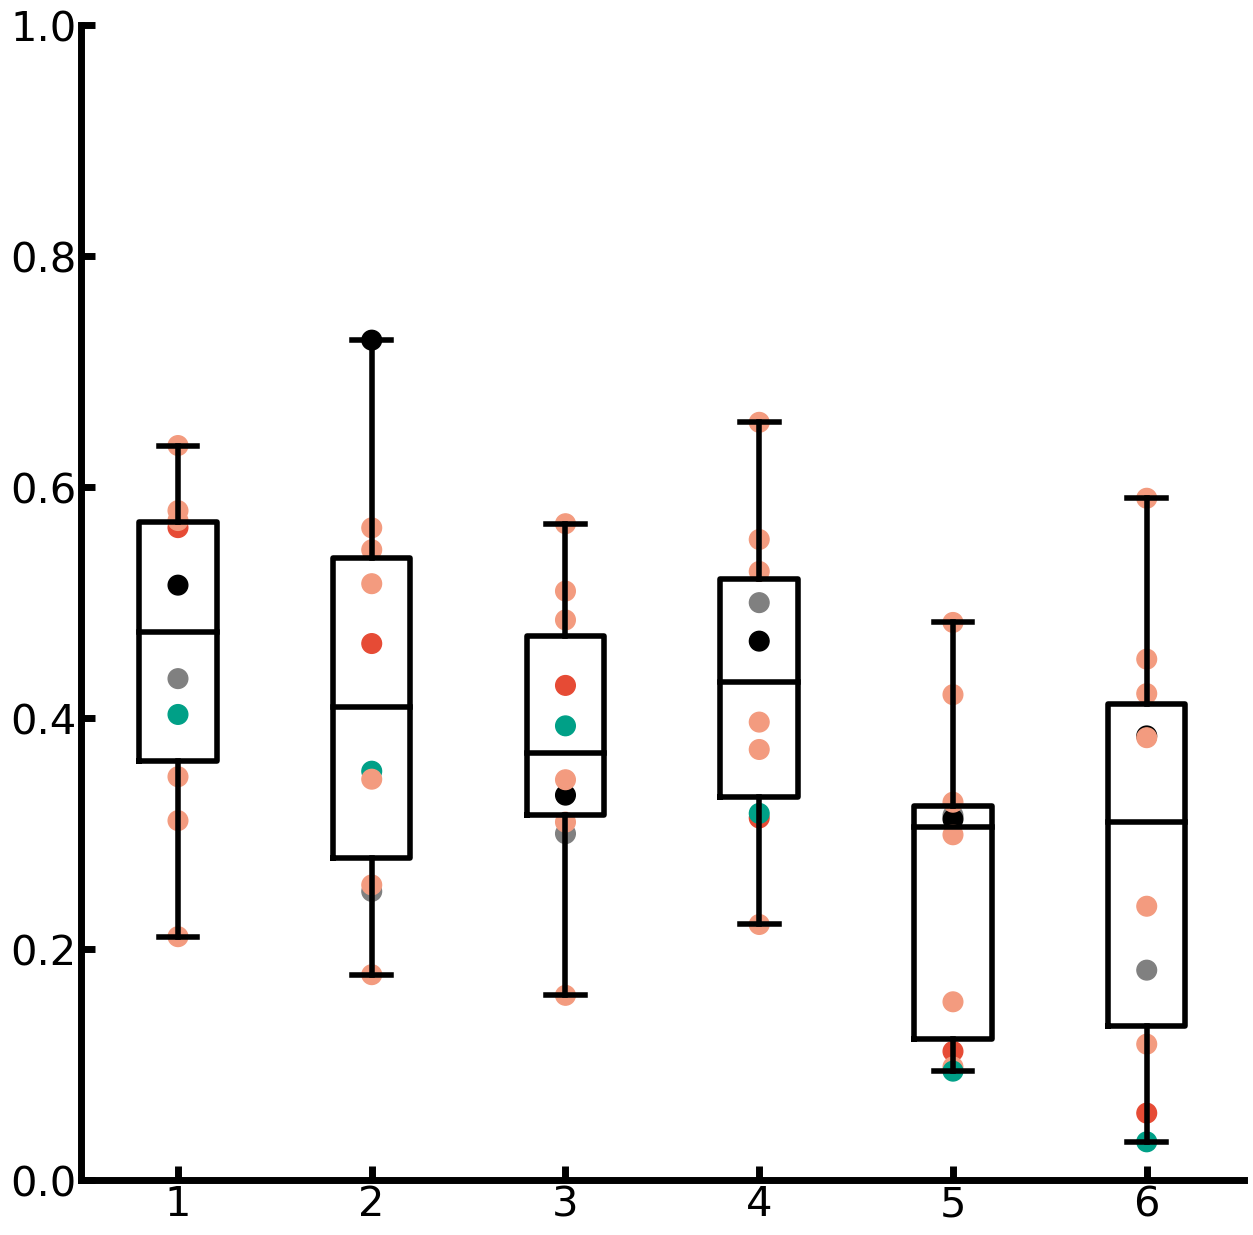

In [159]:
import matplotlib
import matplotlib.font_manager as fm
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

xs_dict = {}
for glc in ['g','l','c']:
    xs_dict[glc] = [[],[],[],[],[],[]]
    for i,condname in enumerate(['normal1']+['blur{}'.format(_) for _ in range(1,6)]):
        for m in effects_results_manipulated_dict[condname].keys():
            nCorrect, N = effects_results_manipulated_dict[condname][m][glc]
            xs_dict[glc][i].append(nCorrect/N)
#             print(nCorrect/N)
        

glc='g'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

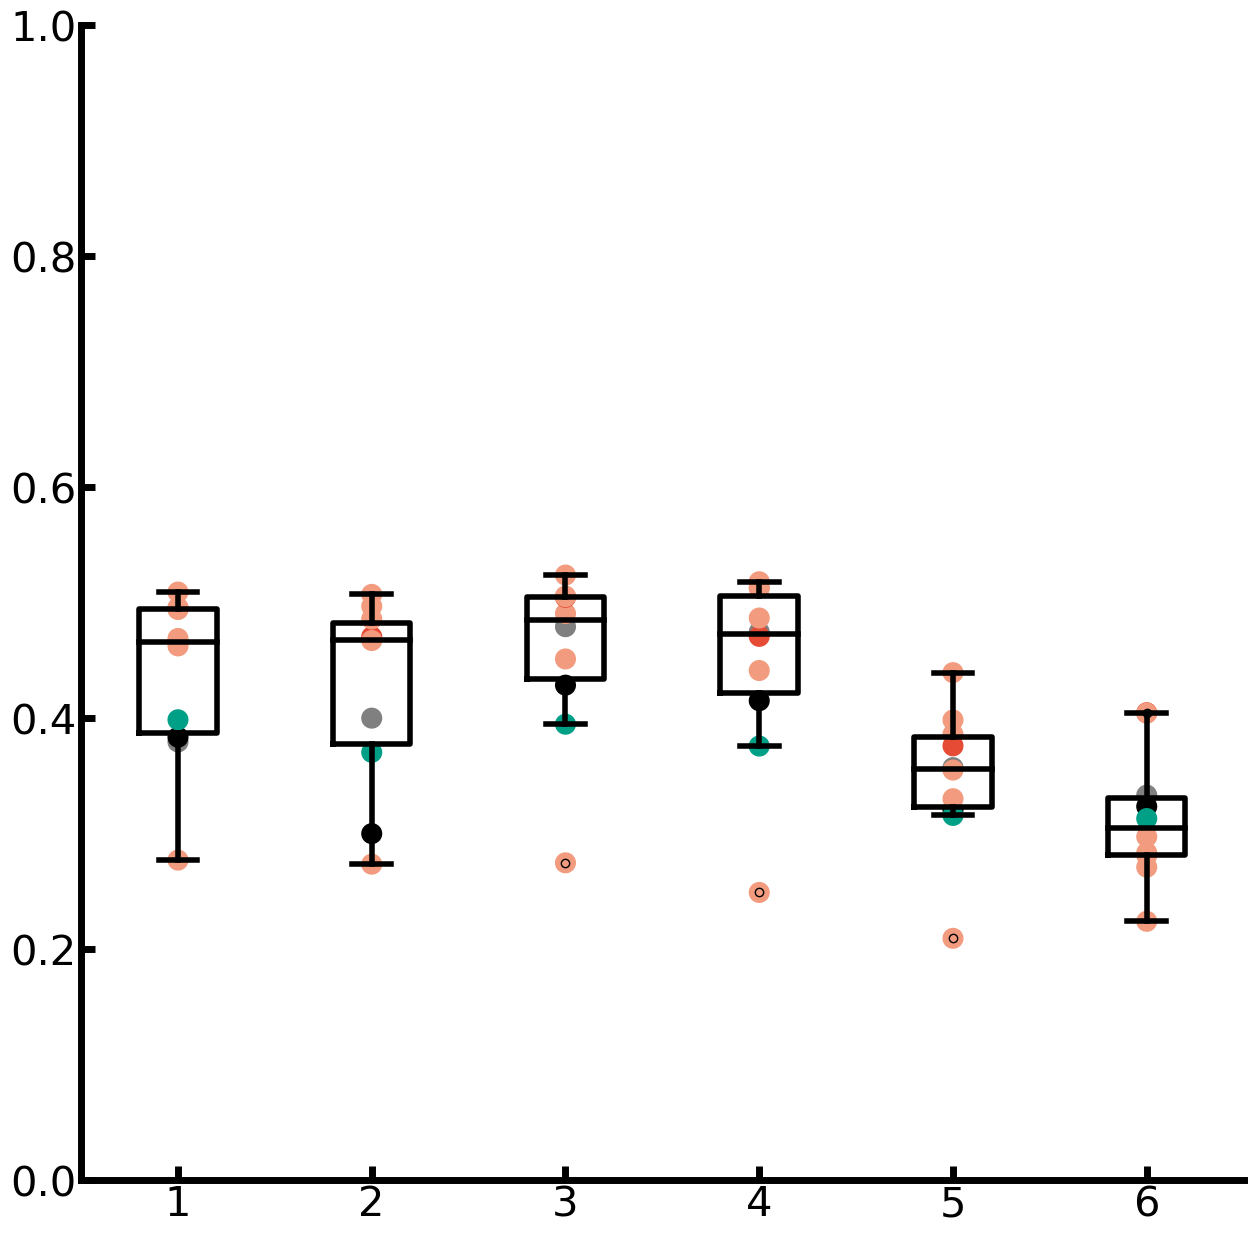

In [160]:
glc='l'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

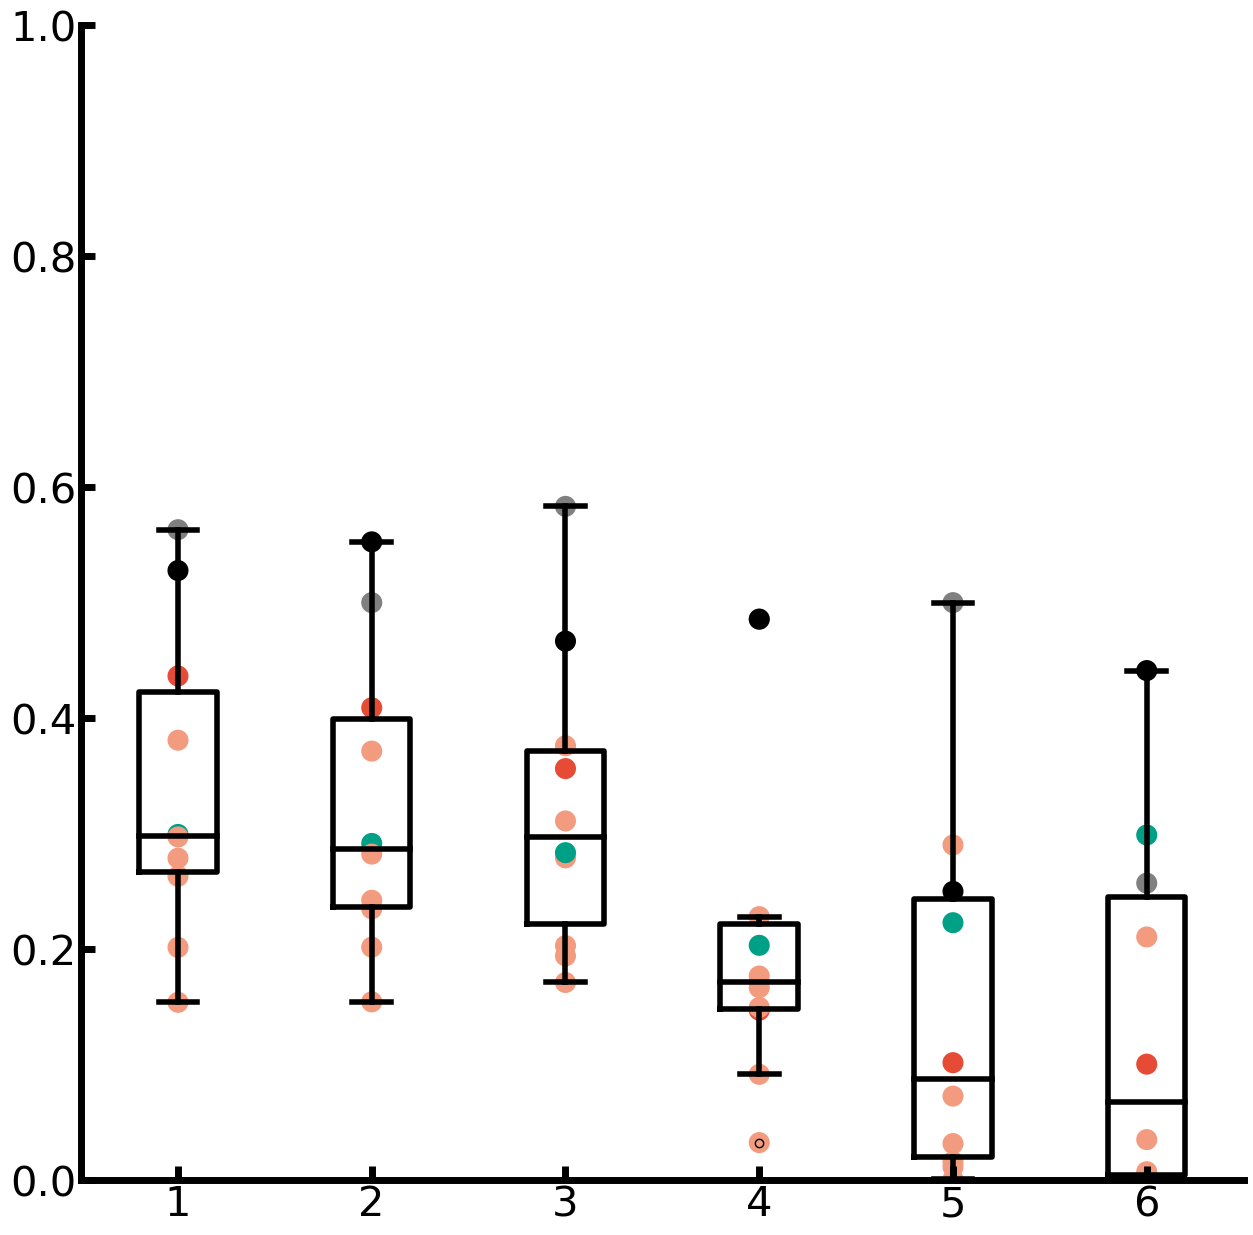

In [161]:
glc='c'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

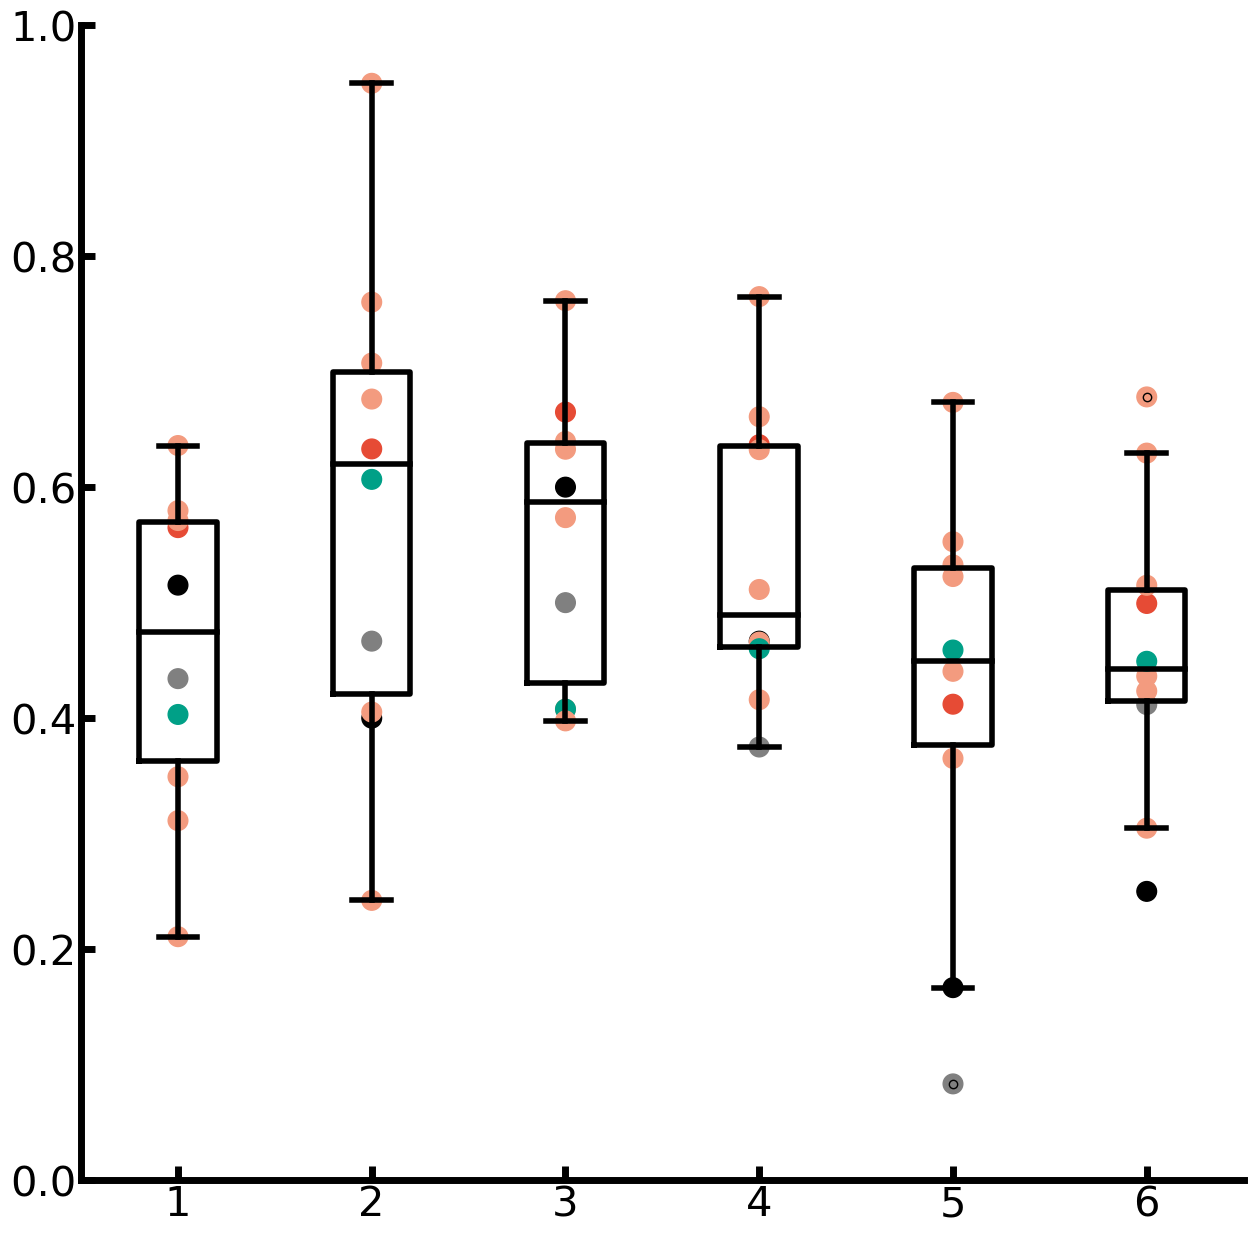

In [35]:
import matplotlib
import matplotlib.font_manager as fm
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

xs_dict = {}
for glc in ['g','l','c']:
    xs_dict[glc] = [[],[],[],[],[],[]]
    for i,condname in enumerate(['normal1']+['amount{}'.format(_) for _ in range(5,0,-1)]):
        for m in effects_results_manipulated_dict[condname].keys():
            nCorrect, N = effects_results_manipulated_dict[condname][m][glc]
            xs_dict[glc][i].append(nCorrect/N)
#             print(nCorrect/N)
        

glc='g'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

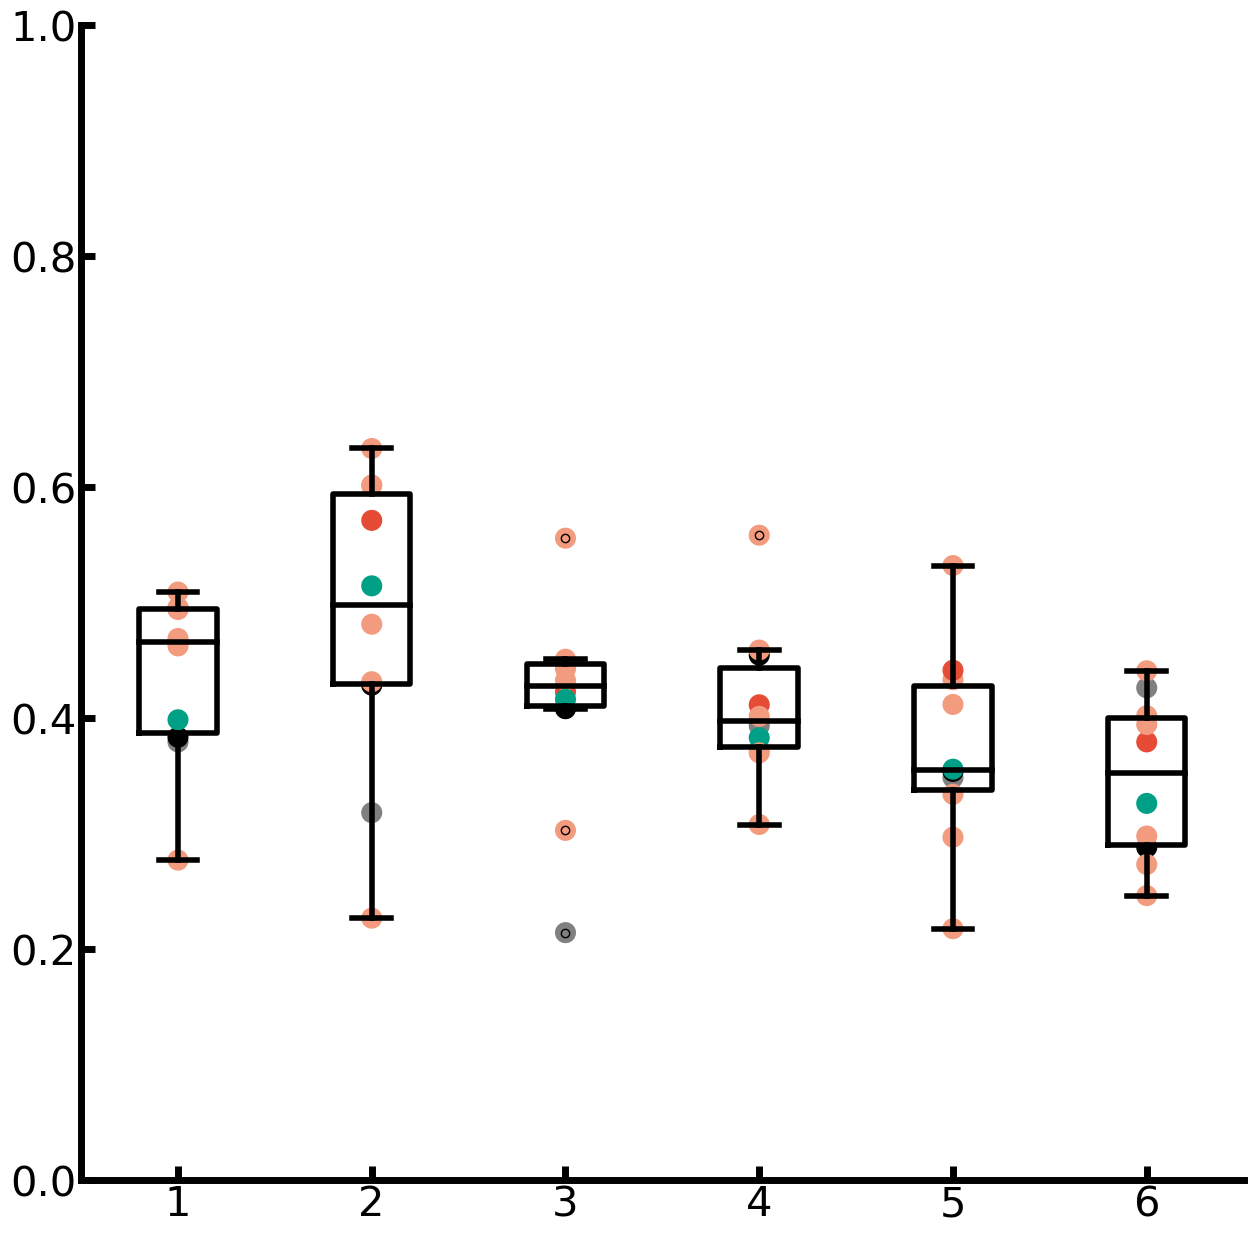

In [36]:
glc='l'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

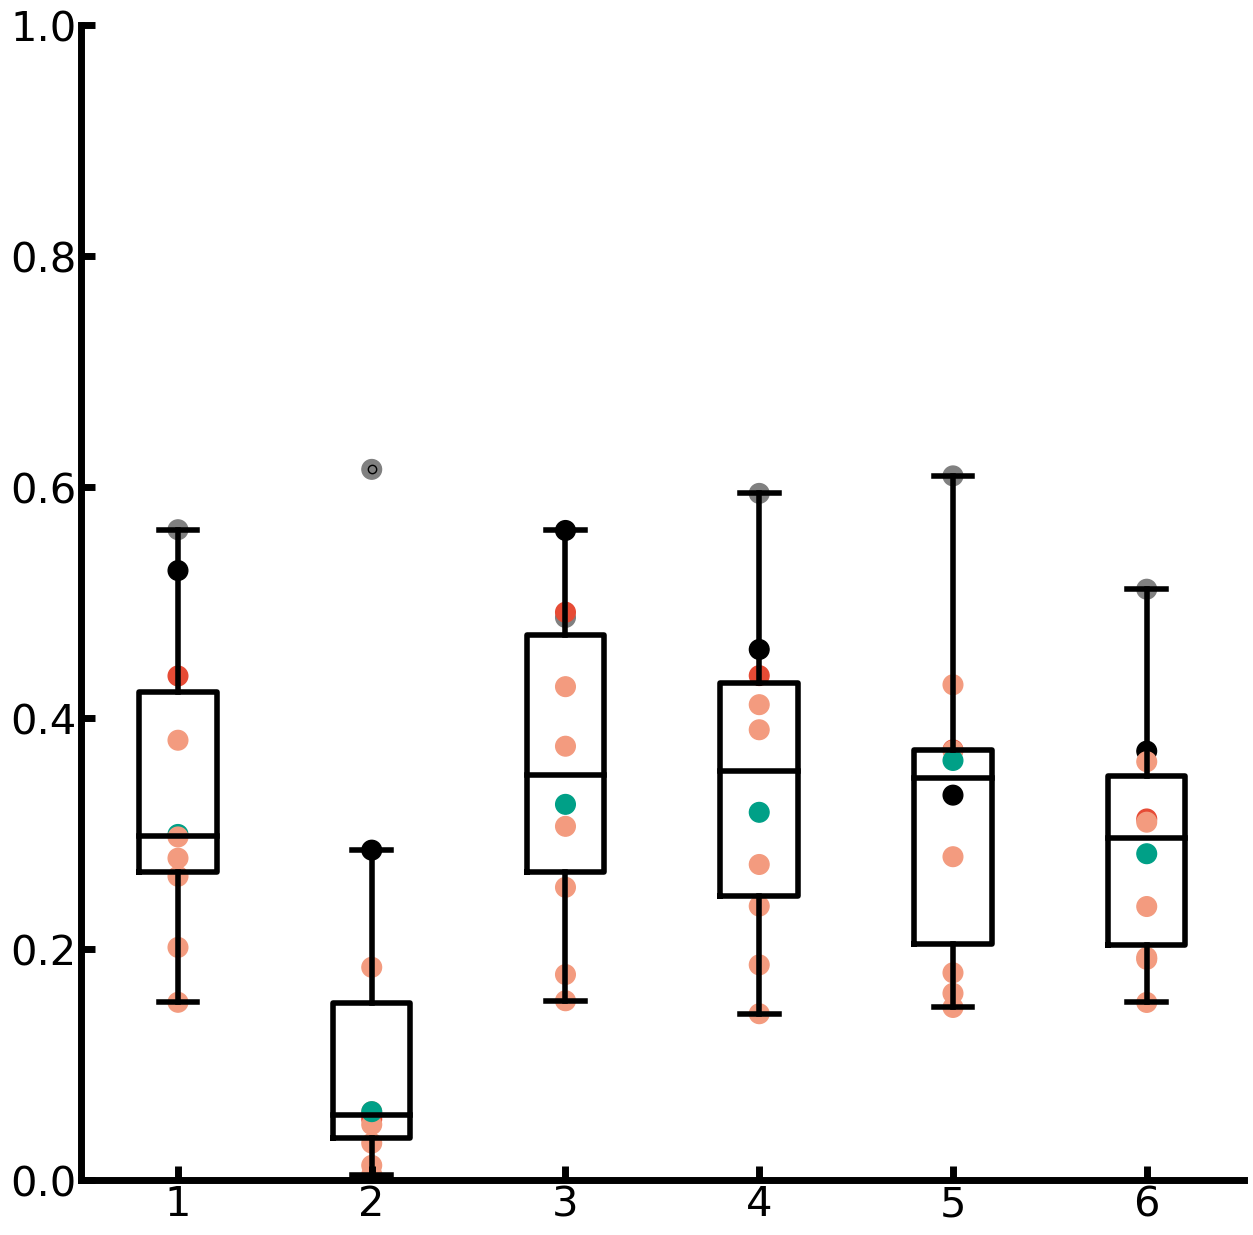

In [37]:
glc='c'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(6):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

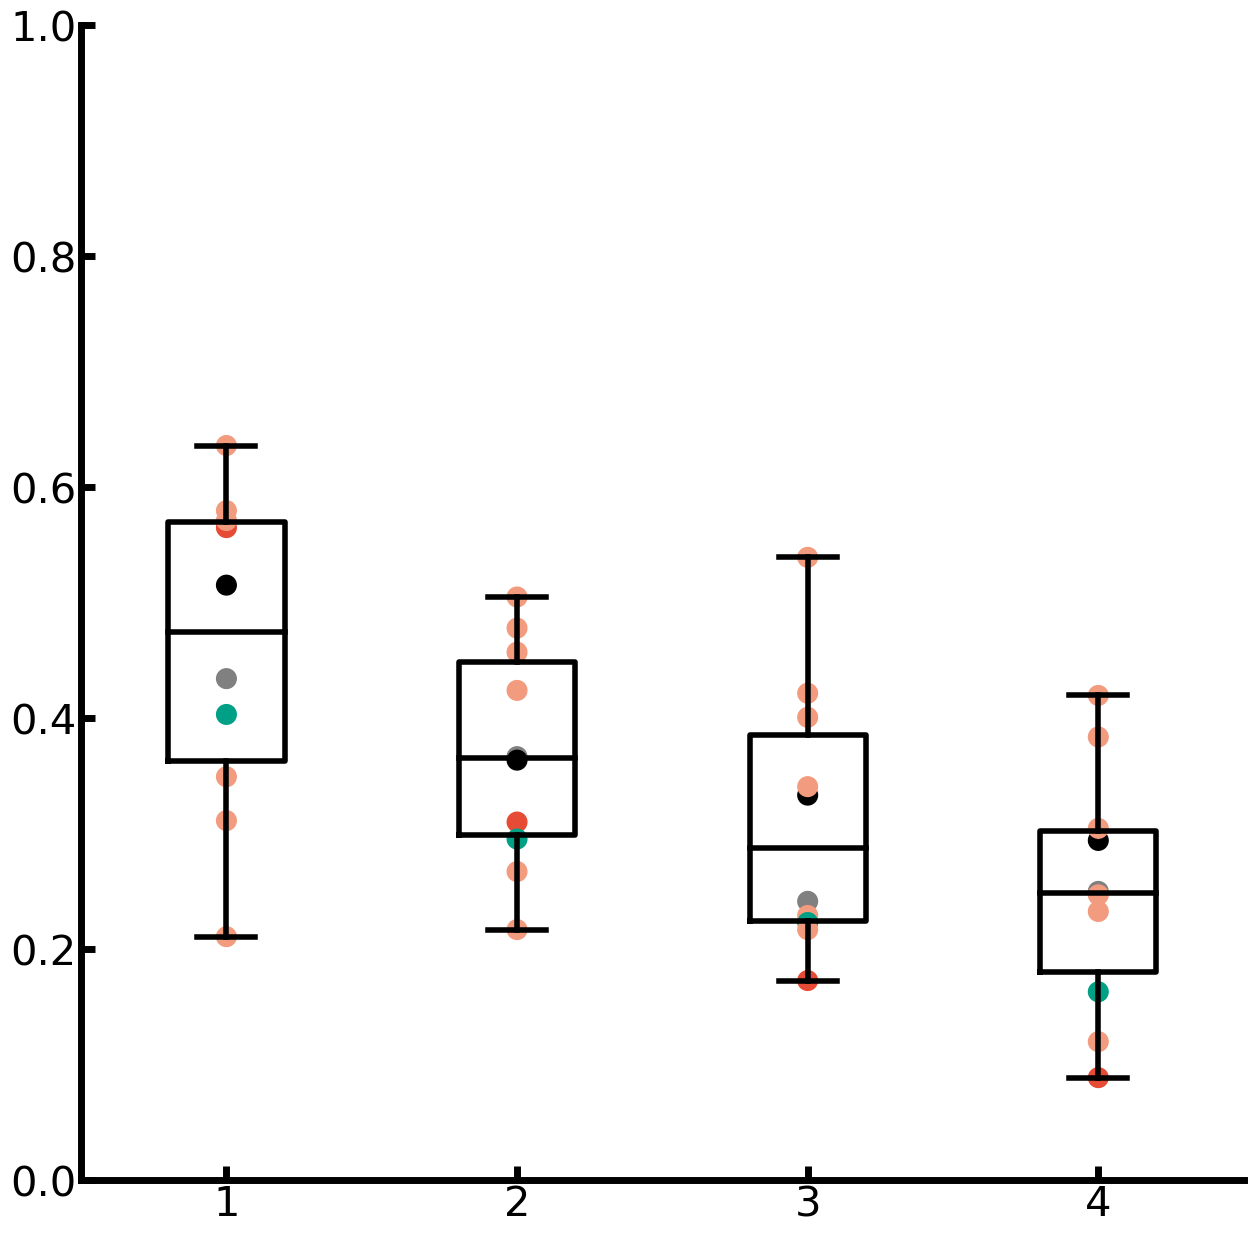

In [169]:
import matplotlib
import matplotlib.font_manager as fm
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

xs_dict = {}
for glc in ['g','l','c']:
    xs_dict[glc] = [[],[],[],[]]
    for i,condname in enumerate(['normal1']+['jigsaw{}'.format(_) for _ in range(1,4)]):
        for m in effects_results_manipulated_dict[condname].keys():
            nCorrect, N = effects_results_manipulated_dict[condname][m][glc]
            xs_dict[glc][i].append(nCorrect/N)
#             print(nCorrect/N)
        

glc='g'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(4):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

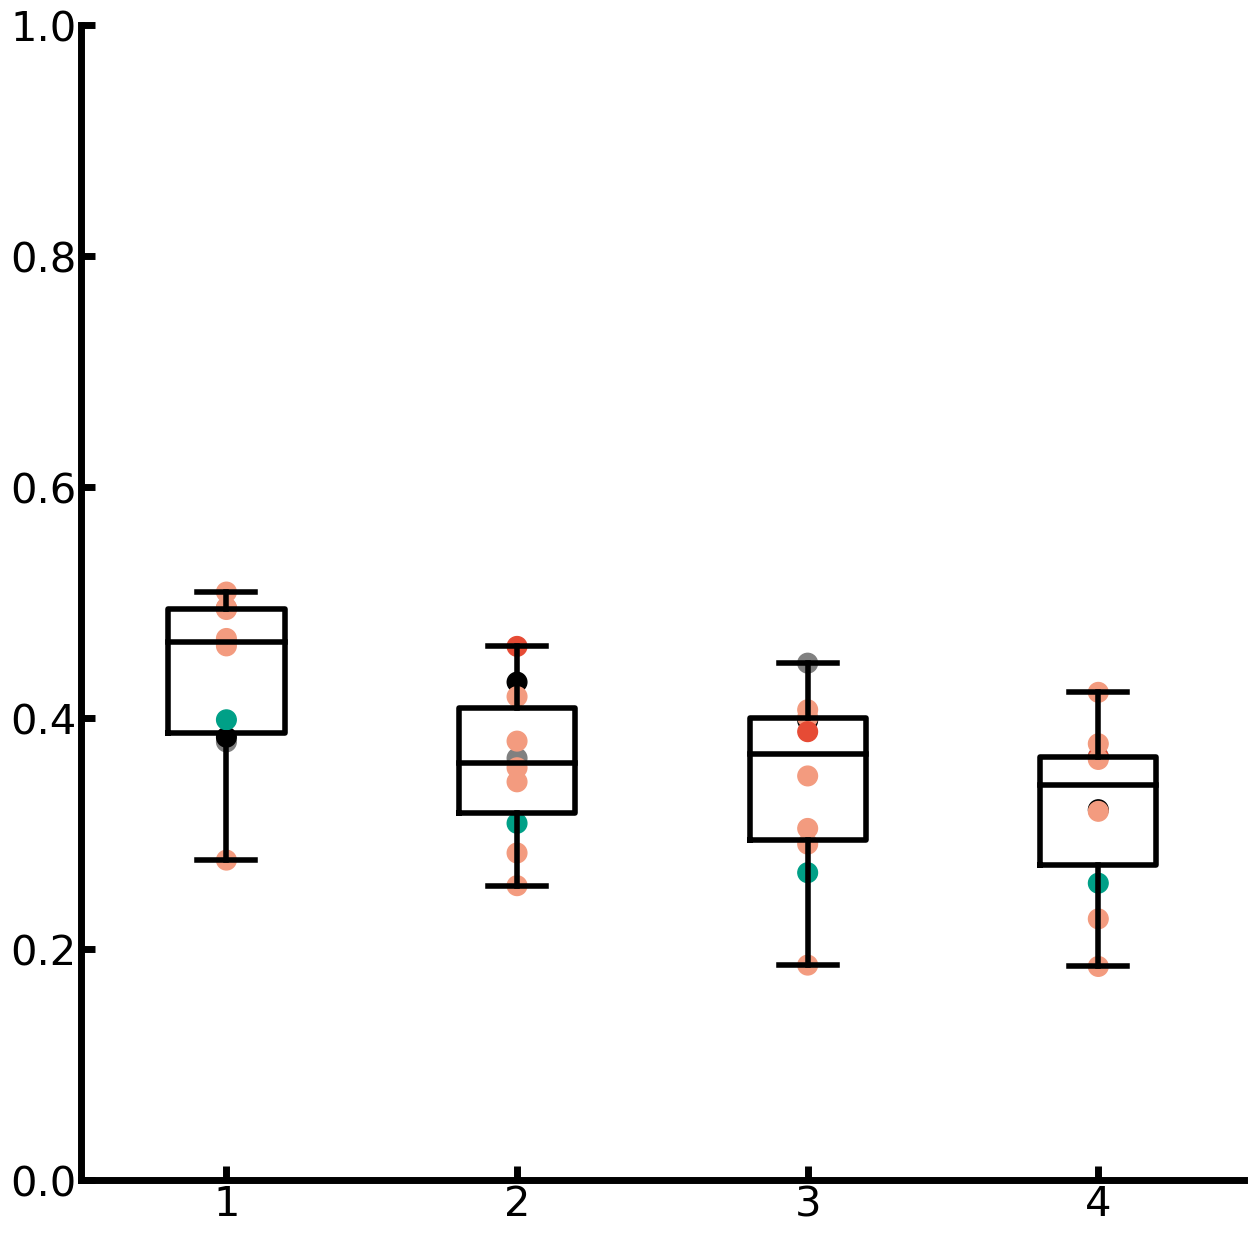

In [170]:
glc='l'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(4):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)

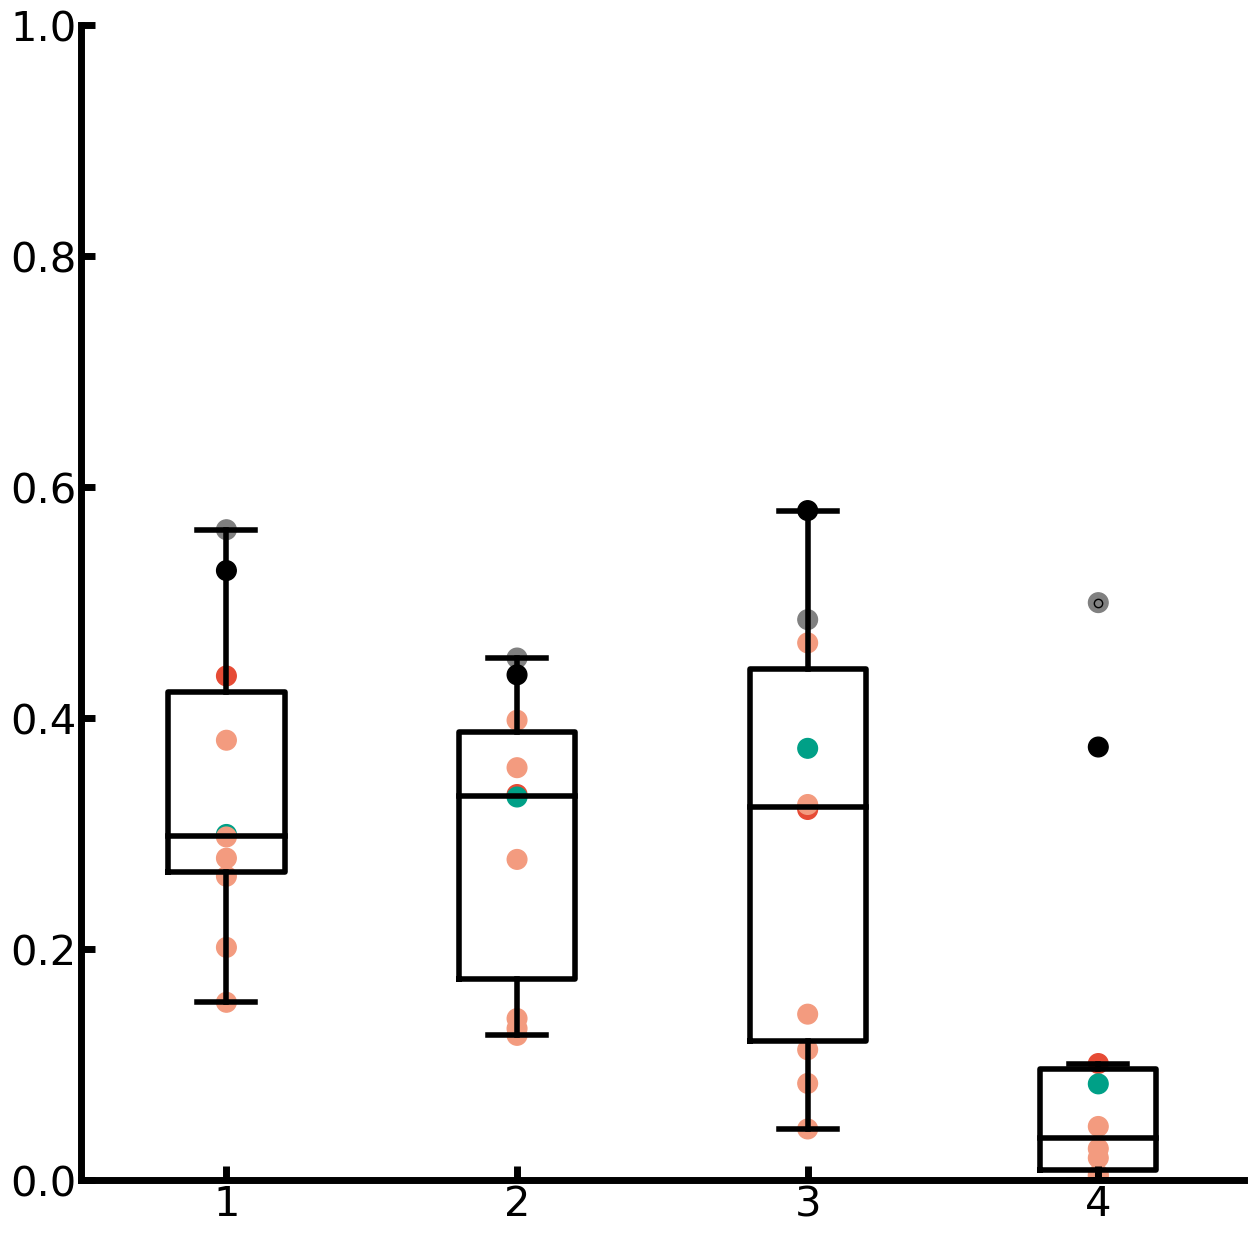

In [171]:
glc='c'
fig, ax = plt.subplots(1, 1,figsize=(15,15))
prop = fm.FontProperties(fname='/home/liuxiao/calibri.ttf')

xs,ys = [],[]
colors = []
for i in range(4):
    xs.extend([i+1]*len(xs_dict[glc][i]))
    ys.extend(xs_dict[glc][i])
    colors.extend(['gray','black',"#f39b7f","#e64b35","#f39b7f","#f39b7f","#00a087","#f39b7f","#f39b7f","#f39b7f"])

ax.scatter(xs,ys,s=200,color=colors)
c='black'
lw=4
ax.boxplot(xs_dict[glc], widths=0.4, boxprops=dict(color=c,linewidth=lw),
            capprops=dict(color=c,linewidth=lw),
            whiskerprops=dict(color=c,linewidth=lw),
            flierprops=dict(color=c, markeredgecolor=c,linewidth=lw),
            medianprops=dict(color=c,linewidth=lw))

# ax.plot([-0.05,1.05],[-0.05,1.05],ls='-',color='black',linewidth=5)
# plt.xticks([_*0.1 for _ in range(1,8)],[round(_*0.1,1) for _ in range(1,8)],fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# ax.set_xlim([0.0,0.85])
ax.set_ylim([0.0,1.0])
# ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(5)
ax.tick_params(axis='y',direction='in', length=10,width=5)
ax.tick_params(axis='x',direction='in', length=10,width=5)